<a href="https://www.kaggle.com/code/jlcole/memory-malware-detection-model-nominator?scriptVersionId=155392673" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Model Nomination for Malware Detection using Memory Artifacts
* Jonathan Cole
* Dec 6th, 2023

## Overview

The project goal is to determine an optimal model and method for the effective classification of malware from memory analysis data captures. 

**Note:** 

*- The dataset used for evaluation has not been verified and tested against live data.*

*- The final results analysis vary due to variation within Random Forest predictions.*

### Dataset overvew

The dataset used for model estimation is a pre-labeled collection of plugin utility outputs from the Volality memory analysis framework (ref: https://volatility3.readthedocs.io). The plugins examine patterns to identify locations in memory where process, network, and similar information is stored and return the associated data for analysis. The outputs have been pre-formated into associated feature columns and encoded in a numeric representation. The features are explained in the following section.

* Dataset source: https://www.unb.ca/cic/datasets/malmem-2022.html
* Dataset source paper: https://pdfs.semanticscholar.org/b2e2/0dc7a34753311472a5f2314fbf866d7eddd0.pdf



In [1]:
import numpy as np 
import pandas as pd 

# Visualization requirements
import matplotlib.pyplot as plt
import seaborn as sns

# For model performance reporting
from sklearn import metrics  

# For model export and import
import pickle

In [2]:
# Mute warning messages
import warnings

warnings.filterwarnings('ignore')

## Exploratory Analysis

Descriptions weren't available for all features, but those that were (as identified in the data source paper) are listed below

* FeatureType
  * FeatureList - Feature Description
* Malfind
  * commitCharge - Total number of Commit Charges
  * protection - Total number of protection
  * uniqueInjections - Total number of unique injections
* Ldrmodule
  * avgMissingFromLoad - The average amount of modules missing from the load list
  * avgMissingFromInit - The average amount of modules missing from the initilization list
  * avgMissingFromMem  - The average amount of modules missing from memory
* Handles
  * port - Total number of port handles
  * file - Total number of file handles
  * event - Total number of event handles
  * desktop - Total number of desktop handles 
  * key - Total number of key handles
  * thread - Total number of thread handles
  * directory - Total number of directory handles
  * semaphore - Total number of  semaphore handles
  * timer - Total number of timer handles
  * section - Total number of  section handles
  * mutant - Total number of mutant handles
* Process View
  * pslist - Average false ratio of the process list
  * psscan - Average false ratio of the process scan
  * thrdproc - Average false ratio of the third process
  * pspcid - Average false ratio of the process id
  * session - Average false ratio of the session
  * deskthrd - Average false ratio of the deskthrd
* Apihooks
  * nhooks - Total number of apihooks
  * nhookInLine - Total number of inline apihooks
  * nhooksInUsermode - Total number of apihooks in usermodeml  

Additional research on Volalility's modules resulted in the following supporting information: 

* pslist
  * Lists the processes present in a particular windows memory image.
  * source: https://volatility3.readthedocs.io/en/latest/volatility3.plugins.windows.pslist.html

 
* dlllist
  * Lists the loaded modules in a particular windows memory image.
  * source: https://volatility3.readthedocs.io/en/latest/volatility3.plugins.windows.dlllist.html 


* handles
  * Lists process open handles.
  * soure: - https://volatility3.readthedocs.io/en/latest/volatility3.plugins.windows.handles.html

 
* ldrmodules
  * Lists the loaded modules in a particular windows memory image.
  * source: https://volatility3.readthedocs.io/en/latest/volatility3.plugins.windows.ldrmodules.html


* malfind
  * Lists process memory ranges that potentially contain injected code.
  * source - https://volatility3.readthedocs.io/en/latest/volatility3.plugins.windows.malfind.html


* psxview
  * Helps detect hidden processes by comparing what `PsActiveProcessHead` contains with what is reported by various other sources of process listings.
  * source - https://github.com/volatilityfoundation/volatility/wiki/Command-Reference-Mal#psxview


* modules
  * Lists the loaded kernel modules.
  * source - https://volatility3.readthedocs.io/en/latest/volatility3.plugins.windows.modules.html


* svcscan
  * Scans for windows services.
  * source: - https://volatility3.readthedocs.io/en/latest/volatility3.plugins.windows.svcscan.html

   
* callbacks
  * Lists kernel callbacks and notification routines.
  * source: https://volatility3.readthedocs.io/en/latest/volatility3.plugins.windows.callbacks.html


In [3]:
# load the dataset from local file
file = r'C:\Users\HP\Desktop\New folder (4)\archive (4)\Obfuscated-MalMem2022.csv'
data = pd.read_csv(file)

data.head()

,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
0,Benign,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,...,221,26,24,116,0,121,87,0,8,Benign
1,Benign,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,...,222,26,24,118,0,122,87,0,8,Benign
2,Benign,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,...,222,26,27,118,0,120,88,0,8,Benign
3,Benign,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,...,222,26,27,118,0,120,88,0,8,Benign
4,Benign,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,...,222,26,24,118,0,124,87,0,8,Benign


In [4]:
# Examine features
data.columns

Index(['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads',
       'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls',
       'dlllist.avg_dlls_per_proc', 'handles.nhandles',
       'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile',
       'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread',
       'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer',
       'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load',
       'ldrmodules.not_in_init', 'ldrmodules.not_in_mem',
       'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg',
       'ldrmodules.not_in_mem_avg', 'malfind.ninjections',
       'malfind.commitCharge', 'malfind.protection',
       'malfind.uniqueInjections', 'psxview.not_in_pslist',
       'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool',
       'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles',
       'psxview.not_in_session', 'psxview.not_in_deskthrd',
       'psxv

In [5]:
# Examine statistical summary data for each feature
data.describe().T

,count,mean,std,min,25%,50%,75%,max
pslist.nproc,58596.0,41.394771,5.777249,21.000000,40.000000,41.000000,43.000000,2.400000e+02
pslist.nppid,58596.0,14.713837,2.656748,8.000000,12.000000,15.000000,16.000000,7.200000e+01
pslist.avg_threads,58596.0,11.341655,1.588231,1.650000,9.972973,11.000000,12.861955,1.681818e+01
pslist.nprocs64bit,58596.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
pslist.avg_handlers,58596.0,247.509819,111.857790,34.962500,208.725000,243.963710,289.974322,2.484595e+04
dlllist.ndlls,58596.0,1810.805447,329.782639,670.000000,1556.000000,1735.000000,2087.000000,3.443000e+03
dlllist.avg_dlls_per_proc,58596.0,43.707806,5.742023,7.333333,38.833333,42.781524,49.605280,5.317073e+01
handles.nhandles,58596.0,10258.584221,4866.864130,3514.000000,8393.000000,9287.500000,12193.000000,1.047310e+06
handles.avg_handles_per_proc,58596.0,249.560958,145.999866,71.139241,209.648228,247.208951,291.355050,3.378419e+04
handles.nport,58596.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00


In [6]:
# Identify feature data types and check for any null values (compare Non-Null count to dataset length)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58596 entries, 0 to 58595
Data columns (total 57 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Category                                58596 non-null  object 
 1   pslist.nproc                            58596 non-null  int64  
 2   pslist.nppid                            58596 non-null  int64  
 3   pslist.avg_threads                      58596 non-null  float64
 4   pslist.nprocs64bit                      58596 non-null  int64  
 5   pslist.avg_handlers                     58596 non-null  float64
 6   dlllist.ndlls                           58596 non-null  int64  
 7   dlllist.avg_dlls_per_proc               58596 non-null  float64
 8   handles.nhandles                        58596 non-null  int64  
 9   handles.avg_handles_per_proc            58596 non-null  float64
 10  handles.nport                           58596 non-null  in

### Feature Reduction

Given the high amount of features present, options for feature reduction will be examined to improve model performance (less CPU, memory, dimenisionality) and allow the model to focus on the most relevant data.

Note that in the prior step, all data types are already numeric except for Class and Category, so no encoding techniques will be required for conversion. Class and Category will be examined to potentially serve as target labels based on their descriptive names. 


### Examining features based on unique value counts

Features with without unique value variance do not aid in classification.

In [7]:
for feature in data.columns:

    # Get the number of unique vales for the feature
    unique_count = data[feature].nunique()

    # Print the feature with unique value counts
    if unique_count == 1:
        print(f'{feature} : {unique_count} <--------------------- Removal Candidate')
    else:
        print(f'{feature} : {unique_count}')

Category : 28346
pslist.nproc : 114
pslist.nppid : 49
pslist.avg_threads : 27885
pslist.nprocs64bit : 1 <--------------------- Removal Candidate
pslist.avg_handlers : 36463
dlllist.ndlls : 1860
dlllist.avg_dlls_per_proc : 16319
handles.nhandles : 7674
handles.avg_handles_per_proc : 36144
handles.nport : 1 <--------------------- Removal Candidate
handles.nfile : 1149
handles.nevent : 3469
handles.ndesktop : 64
handles.nkey : 1100
handles.nthread : 1170
handles.ndirectory : 108
handles.nsemaphore : 638
handles.ntimer : 129
handles.nsection : 629
handles.nmutant : 408
ldrmodules.not_in_load : 151
ldrmodules.not_in_init : 185
ldrmodules.not_in_mem : 151
ldrmodules.not_in_load_avg : 18673
ldrmodules.not_in_init_avg : 18838
ldrmodules.not_in_mem_avg : 18673
malfind.ninjections : 120
malfind.commitCharge : 559
malfind.protection : 215
malfind.uniqueInjections : 5526
psxview.not_in_pslist : 41
psxview.not_in_eprocess_pool : 2
psxview.not_in_ethread_pool : 84
psxview.not_in_pspcid_list : 43
psx

The candidates identified to drop are:
* `pslist.nprocs64bit` : 1
* `handles.nport` : 1
* `svcscan.interactive_process_services` : 1


The next step will verify the feature content.

In [8]:
for each in ['handles.nport', 'pslist.nprocs64bit', 'svcscan.interactive_process_services']:
    print(data[each].value_counts())
    print('')

handles.nport
0    58596
Name: count, dtype: int64

pslist.nprocs64bit
0    58596
Name: count, dtype: int64

svcscan.interactive_process_services
0    58596
Name: count, dtype: int64



Drop the nominated features after confirming no useful data exists.

In [9]:
data.drop(['handles.nport', 'pslist.nprocs64bit', 'svcscan.interactive_process_services'], axis=1, inplace=True)

In [10]:
# Re-examine remaining features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58596 entries, 0 to 58595
Data columns (total 54 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Category                                58596 non-null  object 
 1   pslist.nproc                            58596 non-null  int64  
 2   pslist.nppid                            58596 non-null  int64  
 3   pslist.avg_threads                      58596 non-null  float64
 4   pslist.avg_handlers                     58596 non-null  float64
 5   dlllist.ndlls                           58596 non-null  int64  
 6   dlllist.avg_dlls_per_proc               58596 non-null  float64
 7   handles.nhandles                        58596 non-null  int64  
 8   handles.avg_handles_per_proc            58596 non-null  float64
 9   handles.nfile                           58596 non-null  int64  
 10  handles.nevent                          58596 non-null  in

### Encode Object Labels

Examining the candidate Class and Category object-type features.

In [11]:
# Examine the Class feature values
data['Class'].value_counts()

Class
Benign     29298
Malware    29298
Name: count, dtype: int64

Confirmed the feature contains the desired label state for the classification objective; will be encoded to numeric representation for model use.

In [12]:
# Encode with binary values
data['Class'].replace({'Benign':0, 'Malware':1}, inplace=True)

In [13]:
# Confirm the Class feature encoding
data['Class'].value_counts()

Class
0    29298
1    29298
Name: count, dtype: int64

In [14]:
# Examing the values for Category feature.
data['Category'].value_counts()

Category
Benign                                                                                     29298
Spyware-Gator-1bdcd3b777965f67678748d2577b119a275aca9aed9549d45e64e692a54a7b5e-1.raw           2
Spyware-Gator-1bfb316482877ee42e5a5078fef44c0eb51bc44c1e88ecbccd02ce4dc4694bd3-2.raw           2
Spyware-Gator-1bfb316482877ee42e5a5078fef44c0eb51bc44c1e88ecbccd02ce4dc4694bd3-10.raw          2
Spyware-Gator-1bfb316482877ee42e5a5078fef44c0eb51bc44c1e88ecbccd02ce4dc4694bd3-1.raw           2
                                                                                           ...  
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-6.raw           1
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-5.raw           1
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-4.raw           1
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-3.raw           1
Ransomware-Shade-955d

### Feature Engineering

The Category feature contain data that could be useful, but will need to be parsed to extract the useful data into two new fields, Cat1 and Cat2.

Regex will be used to split the Category feature on the '-' character, extracting the first field as Cat1 and the second field as Cat2, and ignoring the remainder. 

* e.g., Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-3.raw results in Cat1: Spyware, Cat2: Gator

In [15]:
# Extract substrings as new feature values
data[['Cat1', 'Cat2']] = data['Category'].str.extract('(\w+)-(\w+)-.*', expand=True)

# Fields for Cat1 and Cat2 that did not match the regex (such as Benign values) result in nulls. Filling nulls as benign to correct
data[['Cat1', 'Cat2']] = data[['Cat1', 'Cat2']].fillna('Benign')

In [16]:
# Verify resultant values are as expected
data[['Cat1', 'Cat2']]

,Cat1,Cat2
0,Benign,Benign
1,Benign,Benign
2,Benign,Benign
3,Benign,Benign
4,Benign,Benign
...,...,...
58591,Ransomware,Shade
58592,Ransomware,Shade
58593,Ransomware,Shade
58594,Ransomware,Shade


In [17]:
# Verifying the value ranges to see the distribution
print(data['Cat1'].value_counts(),'\n')
print(data['Cat2'].value_counts())

Cat1
Benign        29298
Spyware       10020
Ransomware     9791
Trojan         9487
Name: count, dtype: int64 

Cat2
Benign          29298
Transponder      2410
Gator            2200
Shade            2128
Ako              2000
180solutions     2000
CWS              2000
Refroso          2000
Scar             2000
Conti            1988
Emotet           1967
Maze             1958
Zeus             1950
Pysa             1717
Reconyc          1570
TIBS             1410
Name: count, dtype: int64


Sklearn's label encoder willbe used to convert the new features to numeric representation.

In [18]:
from sklearn import preprocessing 

# Instantiate LabelEncoder use fit_transform to encode
label_encoder = preprocessing.LabelEncoder() 
data['Cat1'] = label_encoder.fit_transform(data['Cat1']) 
data['Cat2'] = label_encoder.fit_transform(data['Cat2']) 

# Validate encoding
print(data['Cat1'].value_counts(),'\n')
print(data['Cat2'].value_counts())

Cat1
0    29298
2    10020
1     9791
3     9487
Name: count, dtype: int64 

Cat2
2     29298
14     2410
6      2200
12     2128
1      2000
0      2000
3      2000
10     2000
11     2000
4      1988
5      1967
7      1958
15     1950
8      1717
9      1570
13     1410
Name: count, dtype: int64


In [19]:
# Remove the unneeded 'Category' feature
data.drop(['Category'], axis=1, inplace=True)

In [20]:
def check_feature(feature, df):
    """ Prints whether a feature is present within a given dataframe or not """
    if feature in df.columns:
        print(f'{feature} is present')
    else:
        print(f'{feature} is not present')

# Verify feature is removed
check_feature('Category', data)

Category is not present


### Correlation

Continuing with examining for opportunities to reduce features, correlation will be performed to identify invidual feature importance.

<Axes: >

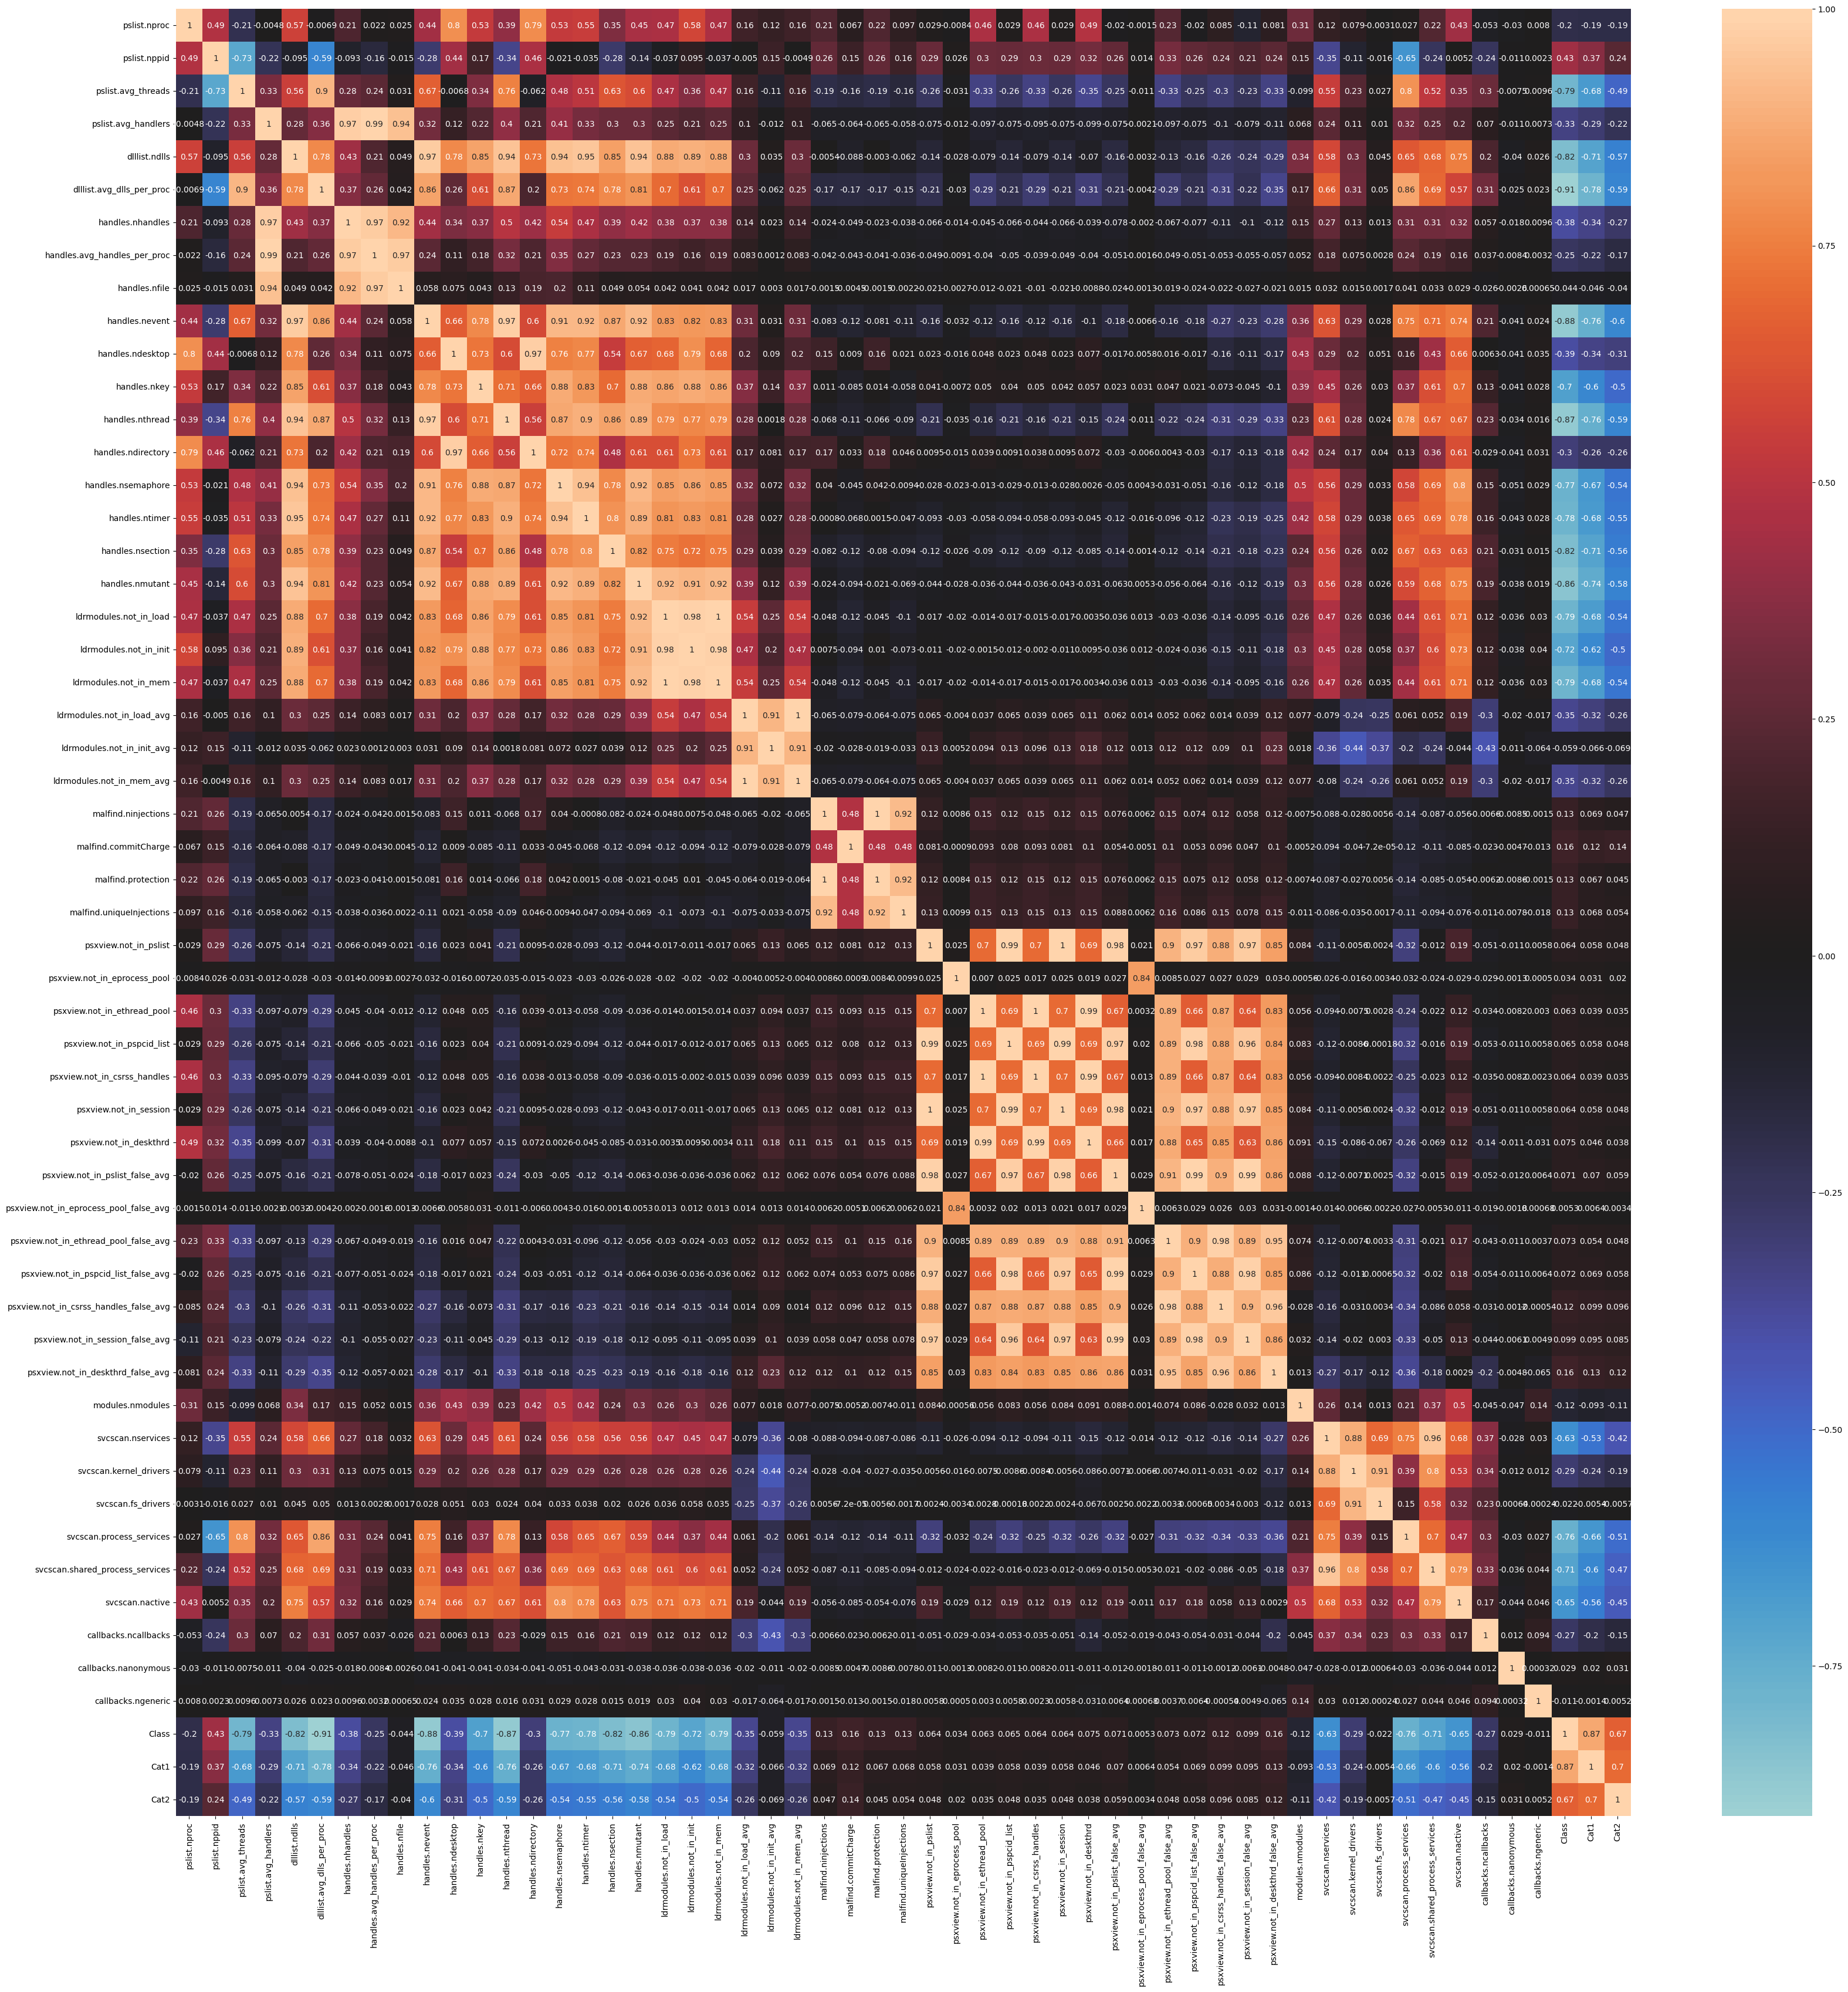

In [21]:
# Get correlation for the feautes within the data dataframe
correlation_matrix = data.corr()

# Plot the associated feature correlation using seaborn's heatmap
plt.figure(figsize=(40,40))
sns.heatmap(correlation_matrix, annot=True, center=0)

In [22]:
# Instantiate a list to append correlation values for later use
correlations = []

# Iterate through each feature to identify each features correlation to 'Class'
for feature in data.columns:

    # derive the correlation to the 'Class' feature
    corr = data['Class'].corr(data[feature]) * 100

    # add absolute values to make positive for comparison (regardless of positive or negative correlation)
    abs_corr = abs(corr)

    # append the correlation value to a list
    correlations.append(abs_corr)

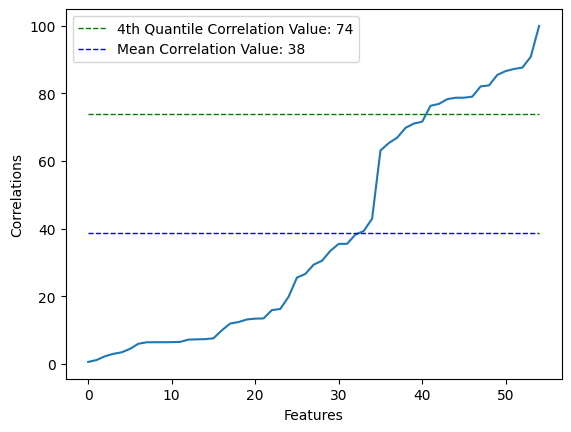

In [23]:
# Prepare to plot correlation list for easier analysis
y = sorted(correlations)
X = [x for x in range(len(y))]

# format x and y values into dataframe for use with SNS lineplot
plt_data = pd.DataFrame({"Correlations":y, "Features":X})

# Determine the correlation mean and 4th Quantile threshold values for plotting
mean = np.mean(correlations)
fourth_quant = np.quantile(correlations, 0.75)

# Plot the correlation values, along with the mean and fourth quantile thresholds
sb_plot = sns.lineplot(data=plt_data, y='Correlations', x = 'Features')

# Add line for 4th Quantile 
sb_plot.hlines(y=fourth_quant, xmin=min(X), xmax=max(X), linewidth=1, color='green', label=f'4th Quantile Correlation Value: {int(fourth_quant)}', ls='--')

# Add line for the mean
sb_plot.hlines(y=mean, xmin=min(X), xmax=max(X), linewidth=1, color='blue', label=f'Mean Correlation Value: {int(mean)}', ls='--')

plt.legend()
plt.show()

Based on the 4th Quantile value, 74 appears to be a good candidate for a correlation threshold to identify which featues to keep. Features below that threshold will be removed.

In [24]:
high_correlation_threshold = fourth_quant # equals 74

# Append to high correlation features to a list
hc_features = []

# Iterate through each feature to identify features with a high correlation to 'Class'
for feature in data.columns:

    corr = data['Class'].corr(data[feature]) * 100

    # add absolute to make positive for comparison (regardless of positive or negative correlation)
    abs_corr = abs(corr)
    
    if abs_corr > high_correlation_threshold:
        print('[*] {} : {} <---------------- High Correlation (> {:.2f}%)'.format(feature, corr, high_correlation_threshold))
        hc_features.append(feature)
    else:
        print('[*] {} : {}'.format(feature, corr))

[*] pslist.nproc : -19.837481909254542
[*] pslist.nppid : 42.9411645000134
[*] pslist.avg_threads : -79.06662320068575 <---------------- High Correlation (> 74.01%)
[*] pslist.avg_handlers : -33.409821936844686
[*] dlllist.ndlls : -82.39325407138021 <---------------- High Correlation (> 74.01%)
[*] dlllist.avg_dlls_per_proc : -90.85545402033199 <---------------- High Correlation (> 74.01%)
[*] handles.nhandles : -38.22695603229509
[*] handles.avg_handles_per_proc : -25.4924650566281
[*] handles.nfile : -4.38970281790773
[*] handles.nevent : -87.67698233918229 <---------------- High Correlation (> 74.01%)
[*] handles.ndesktop : -39.29189564980268
[*] handles.nkey : -69.82394072906524
[*] handles.nthread : -87.25312371303387 <---------------- High Correlation (> 74.01%)
[*] handles.ndirectory : -30.482260992416577
[*] handles.nsemaphore : -76.90968281938315 <---------------- High Correlation (> 74.01%)
[*] handles.ntimer : -78.3137367153138 <---------------- High Correlation (> 74.01%)
[

In [25]:
# Create new datafram with the highly correlated features
hc_data = pd.DataFrame(data[hc_features])
hc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58596 entries, 0 to 58595
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pslist.avg_threads         58596 non-null  float64
 1   dlllist.ndlls              58596 non-null  int64  
 2   dlllist.avg_dlls_per_proc  58596 non-null  float64
 3   handles.nevent             58596 non-null  int64  
 4   handles.nthread            58596 non-null  int64  
 5   handles.nsemaphore         58596 non-null  int64  
 6   handles.ntimer             58596 non-null  int64  
 7   handles.nsection           58596 non-null  int64  
 8   handles.nmutant            58596 non-null  int64  
 9   ldrmodules.not_in_load     58596 non-null  int64  
 10  ldrmodules.not_in_mem      58596 non-null  int64  
 11  svcscan.process_services   58596 non-null  int64  
 12  Class                      58596 non-null  int64  
 13  Cat1                       58596 non-null  int

<Axes: >

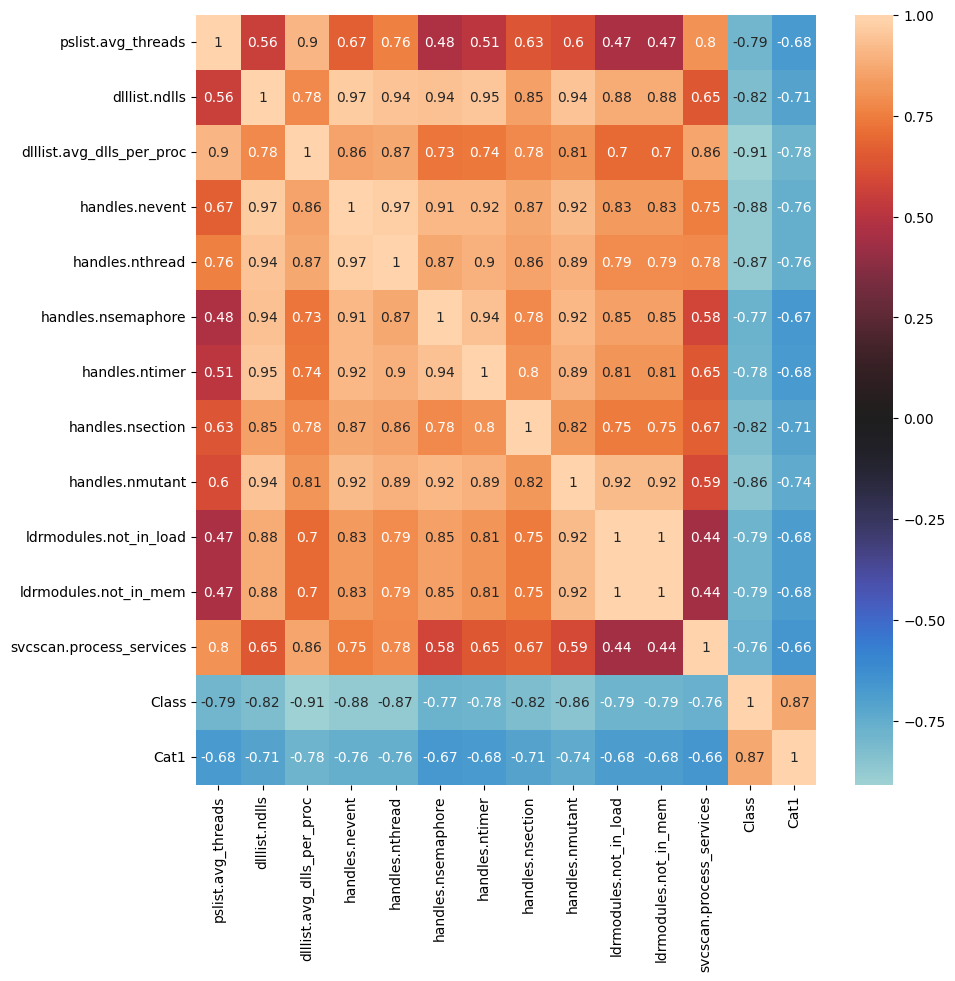

In [26]:
# Get correlation for the feautes within the hc_data dataframe
correlation_matrix = hc_data.corr()

# Plot the associated feature correlation using seaborn's heatmap
plt.figure(figsize=(10,10))
sns.heatmap(correlation_matrix, annot=True, center=0)

## Data Wrangling

### Scaling

Scaling helps reduce distance between feature value ranges while preserving much of the associated relationship. Normalizing the data in this way helps aid in efficacy of many model algorithms and reduces computational overhead.

In [27]:
from sklearn.preprocessing import StandardScaler

# Make a copy of data for scaling
ds = hc_data.copy()

# scale data with Standard Scaler
scaler = StandardScaler()
scaler.fit(ds)
scaled_ds = pd.DataFrame(scaler.transform(ds), columns=ds.columns)

# get a list of the features
features = list(scaled_ds.columns)

In [28]:
scaled_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
pslist.avg_threads,58596.0,-7.915938e-16,1.000009,-6.102222,-0.861773,-0.215119,0.957237,3.448222
dlllist.ndlls,58596.0,-1.319323e-16,1.000009,-3.459294,-0.772653,-0.229867,0.837512,4.949346
dlllist.avg_dlls_per_proc,58596.0,-1.404691e-15,1.000009,-6.334838,-0.848919,-0.161318,1.027081,1.648027
handles.nevent,58596.0,-2.095395e-16,1.000009,-3.235953,-0.806266,-0.523196,0.929402,5.362928
handles.nthread,58596.0,1.552145e-17,1.000009,-2.272812,-0.927232,-0.338540,1.011246,19.798916
handles.nsemaphore,58596.0,4.384809e-16,1.000009,-4.097516,-0.733514,0.006989,0.705178,37.920770
handles.ntimer,58596.0,9.312868e-17,1.000009,-4.098048,-0.690128,0.044914,0.779956,16.817228
handles.nsection,58596.0,-1.241716e-16,1.000009,-1.664343,-0.784096,-0.458335,0.865502,99.785916
handles.nmutant,58596.0,-4.346005e-16,1.000009,-2.659314,-0.746029,-0.322373,0.729934,3.695527
ldrmodules.not_in_load,58596.0,-1.474537e-16,1.000009,-2.922530,-0.790477,-0.204163,0.701960,9.549979


### Outliers

Outlier feature values can have a significant impact on the efficacy of a model. One methods to remove outliers includes dataset reduction based pruning values outside of the second and third Inter Quartile Ranges (IQR).  

In [30]:
# Boxplotting features for outlier visualization

def gen_boxplot(features, data):
    # Creating individual subplots for each feature
    num_features = len(features)
    num_rows = 4
    num_cols = 4
    
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12,16)) # Adjust the figure size if 
    
    # Flatten the axes array for easy iteration
    axes = axes.flatten()
    
    # Creating boxplots for selected features with individual y-axis
    for i, feature in enumerate(features):
        if i < num_features:
            sns.boxplot(data=data[feature], ax=axes[i])
            axes[i].set_title(f'Boxplot of {feature}')
            axes[i].set_ylabel('Values')
            
            # Set individual y-axis limits for each subplot
            axes[i].set_ylim(data[feature].min(), data[feature].max())
    
    # Hide empty subbplots
    for i in range(num_features, num_rows * num_cols):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

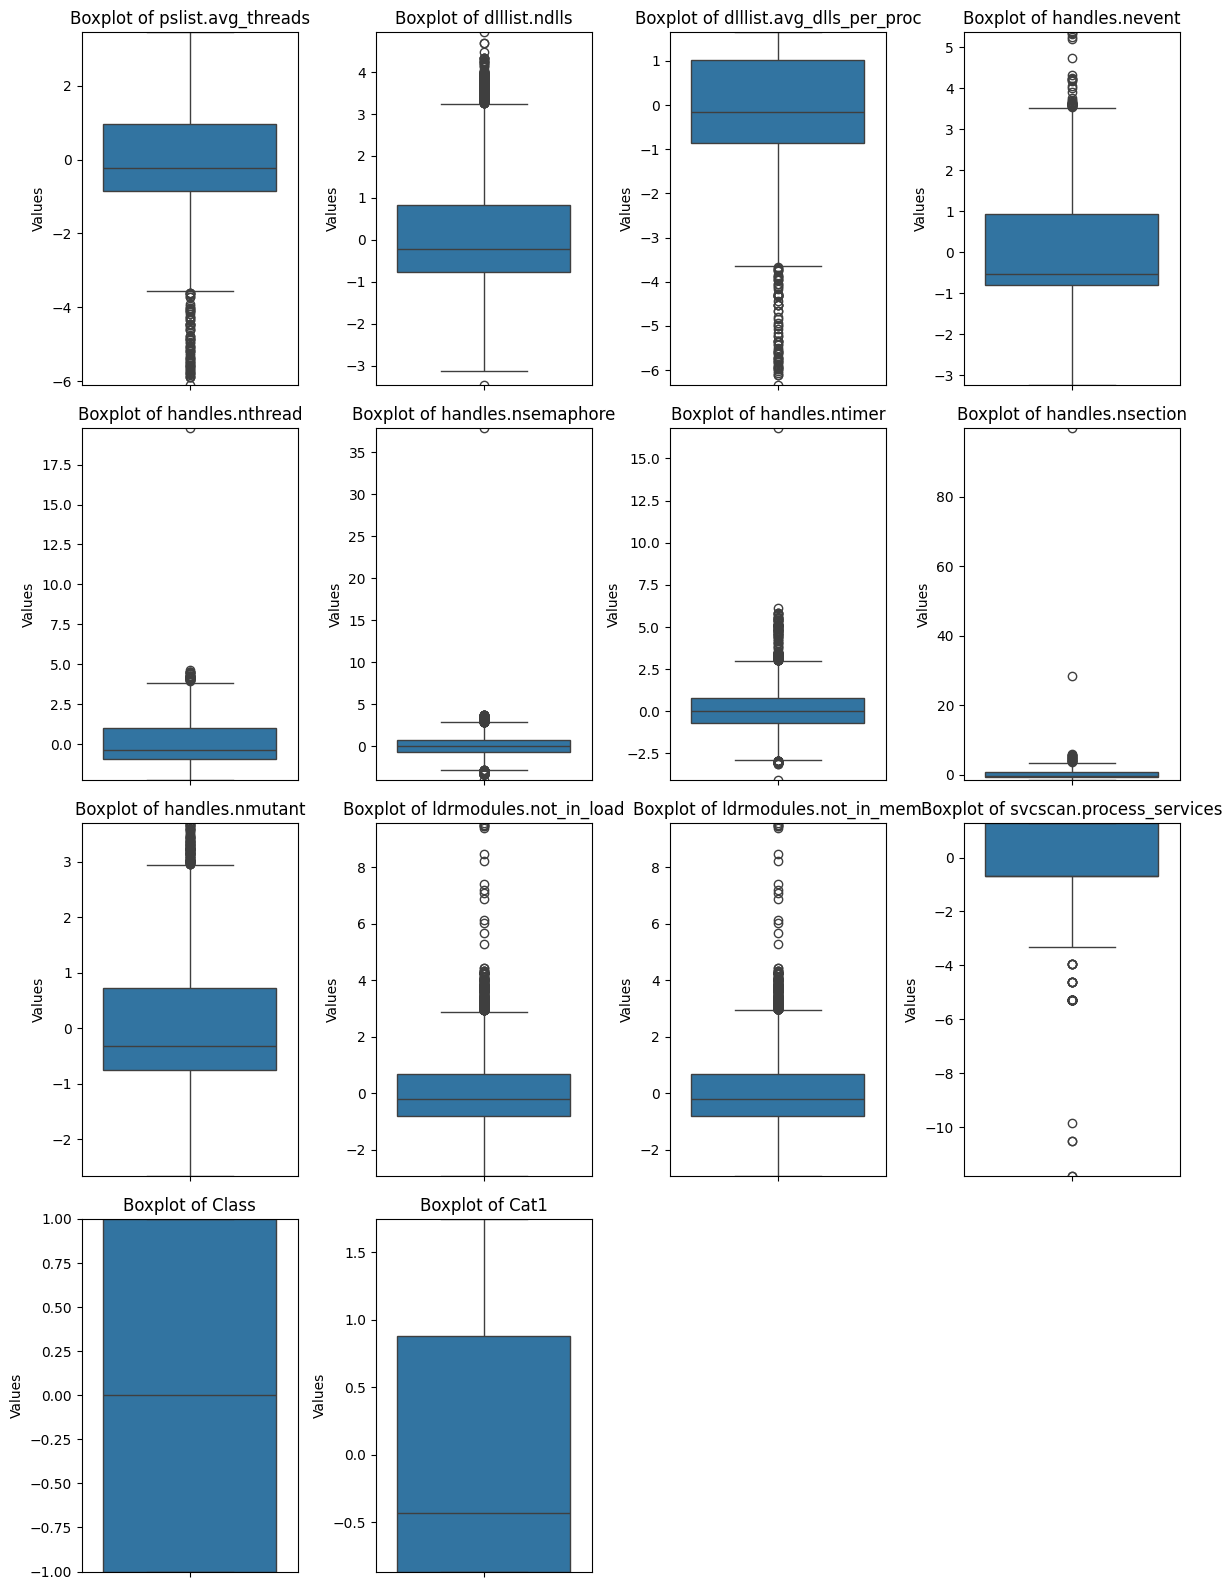

In [31]:
gen_boxplot(features, scaled_ds)

In [32]:
# Get current data length prior to reduction 
scaled_ds_len_1 = scaled_ds.shape[0]
print(f'Data length: {scaled_ds_len_1 }')

# Data summary
scaled_ds.describe().T

Data length: 58596


,count,mean,std,min,25%,50%,75%,max
pslist.avg_threads,58596.0,-7.915938e-16,1.000009,-6.102222,-0.861773,-0.215119,0.957237,3.448222
dlllist.ndlls,58596.0,-1.319323e-16,1.000009,-3.459294,-0.772653,-0.229867,0.837512,4.949346
dlllist.avg_dlls_per_proc,58596.0,-1.404691e-15,1.000009,-6.334838,-0.848919,-0.161318,1.027081,1.648027
handles.nevent,58596.0,-2.095395e-16,1.000009,-3.235953,-0.806266,-0.523196,0.929402,5.362928
handles.nthread,58596.0,1.552145e-17,1.000009,-2.272812,-0.927232,-0.338540,1.011246,19.798916
handles.nsemaphore,58596.0,4.384809e-16,1.000009,-4.097516,-0.733514,0.006989,0.705178,37.920770
handles.ntimer,58596.0,9.312868e-17,1.000009,-4.098048,-0.690128,0.044914,0.779956,16.817228
handles.nsection,58596.0,-1.241716e-16,1.000009,-1.664343,-0.784096,-0.458335,0.865502,99.785916
handles.nmutant,58596.0,-4.346005e-16,1.000009,-2.659314,-0.746029,-0.322373,0.729934,3.695527
ldrmodules.not_in_load,58596.0,-1.474537e-16,1.000009,-2.922530,-0.790477,-0.204163,0.701960,9.549979


In [33]:
# Remove all data values that don't fall within the second and third quantiles (remove Q1 and Q4 for outlier reduction)
for feature in features:
    Q1 = scaled_ds[feature].quantile(0.25)
    Q3 = scaled_ds[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    scaled_ds = scaled_ds[~((scaled_ds[feature] < (Q1 - 1.5 * IQR)) | (scaled_ds[feature] > (Q3 + 1.5 * IQR)))]

In [34]:
# Get current data length post-reduction 
scaled_ds_len_2 = scaled_ds.shape[0]
print(f'Data length: {scaled_ds_len_2 }')
print(f'Rows removed: {scaled_ds_len_1 - scaled_ds_len_2}')
# Data summary
scaled_ds.describe().T

Data length: 56874
Rows removed: 1722


,count,mean,std,min,25%,50%,75%,max
pslist.avg_threads,56874.0,-0.007321,0.965660,-3.570712,-0.876237,-0.223135,0.956298,2.998508
dlllist.ndlls,56874.0,0.003095,0.904607,-3.137868,-0.769621,-0.217738,0.831447,3.248211
dlllist.avg_dlls_per_proc,56874.0,0.015454,0.984987,-3.641664,-0.841663,-0.107722,1.030516,1.648027
handles.nevent,56874.0,0.011815,0.934782,-2.170715,-0.801300,-0.490916,0.923194,3.442271
handles.nthread,56874.0,0.002402,0.960766,-1.742990,-0.914617,-0.321720,1.007041,3.820145
handles.nsemaphore,56874.0,0.020339,0.873270,-2.912711,-0.712357,0.070461,0.705178,2.873796
handles.ntimer,56874.0,0.017669,0.903141,-2.761609,-0.690128,0.044914,0.779956,2.985081
handles.nsection,56874.0,-0.000128,0.865817,-1.484135,-0.784096,-0.413283,0.865502,3.256725
handles.nmutant,56874.0,0.004062,0.947469,-1.798336,-0.732362,-0.267707,0.729934,2.916546
ldrmodules.not_in_load,56874.0,-0.006288,0.928762,-2.869228,-0.790477,-0.204163,0.701960,2.887314


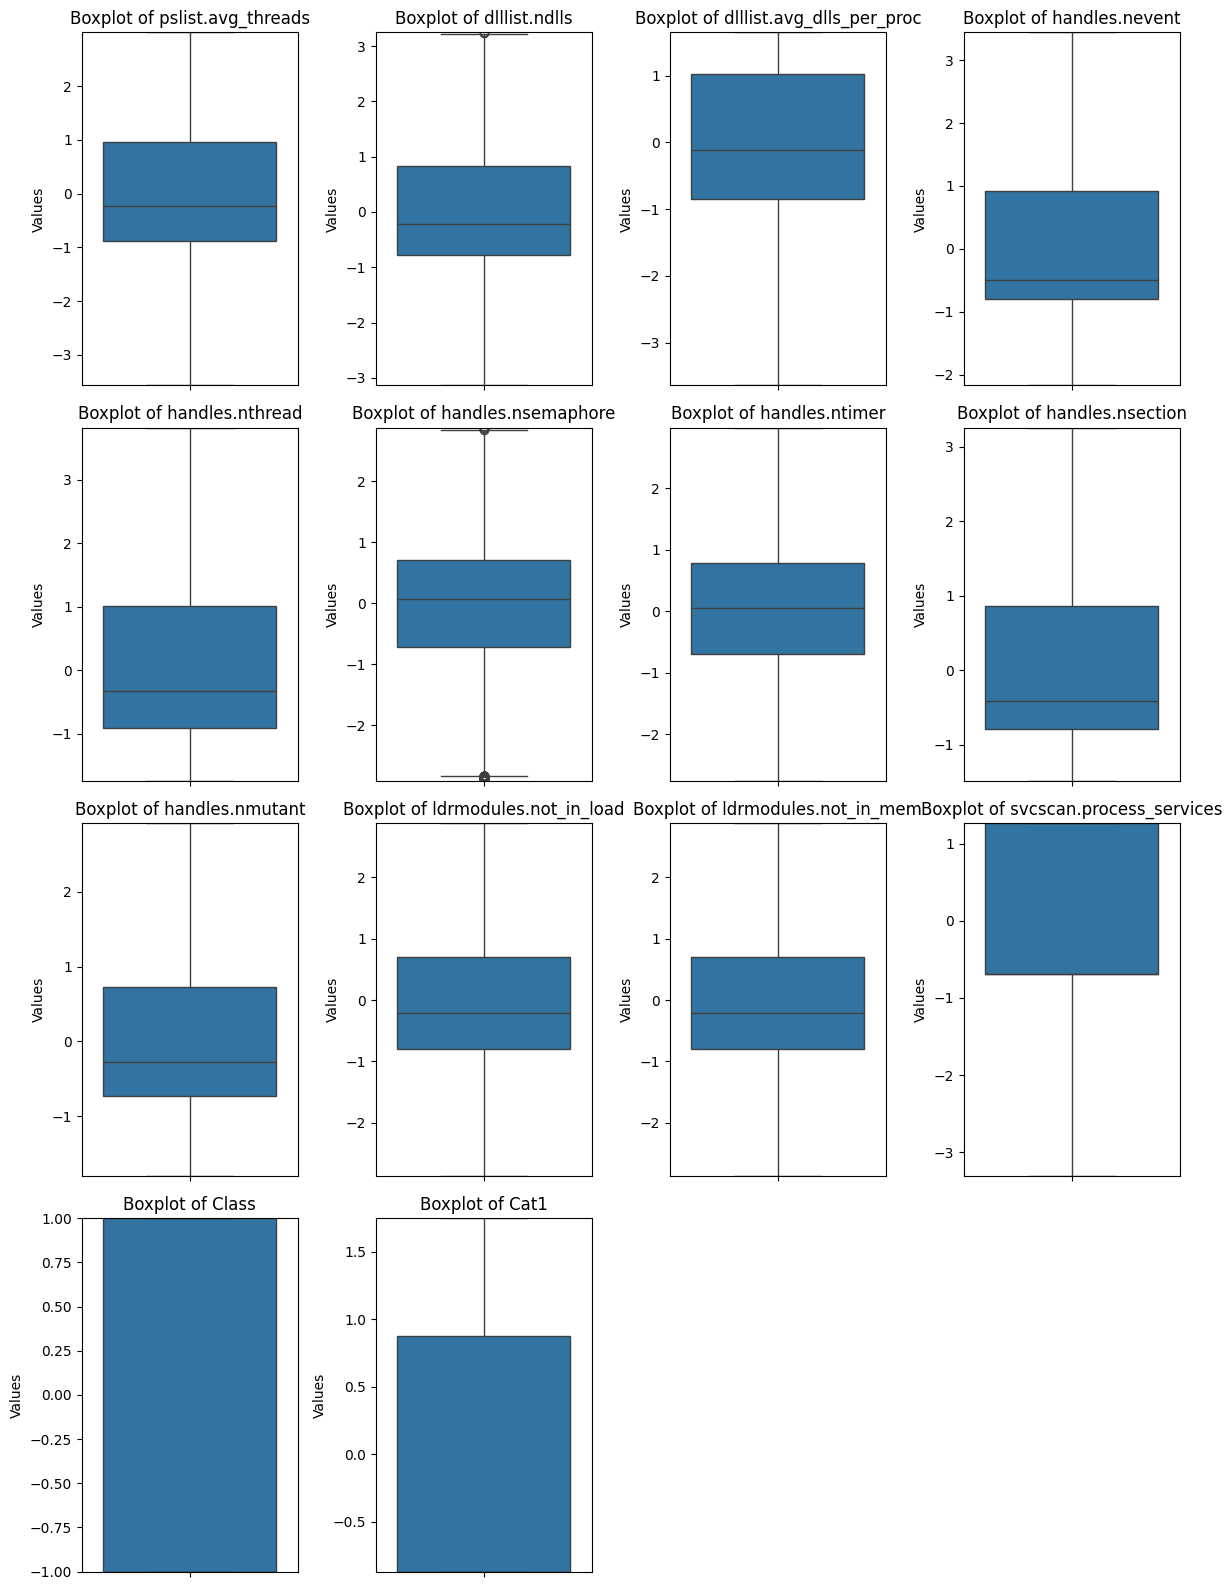

In [35]:
gen_boxplot(features, scaled_ds)

### Analyze Feature Distribution

Visualization of the target label feature distrubtion in relation the various features can highlight the correlation relationship and association patterns.  

In [36]:
# Removing the target label features from the feature list
features.remove('Class')
features.remove('Cat1')
features

['pslist.avg_threads',
 'dlllist.ndlls',
 'dlllist.avg_dlls_per_proc',
 'handles.nevent',
 'handles.nthread',
 'handles.nsemaphore',
 'handles.ntimer',
 'handles.nsection',
 'handles.nmutant',
 'ldrmodules.not_in_load',
 'ldrmodules.not_in_mem',
 'svcscan.process_services']

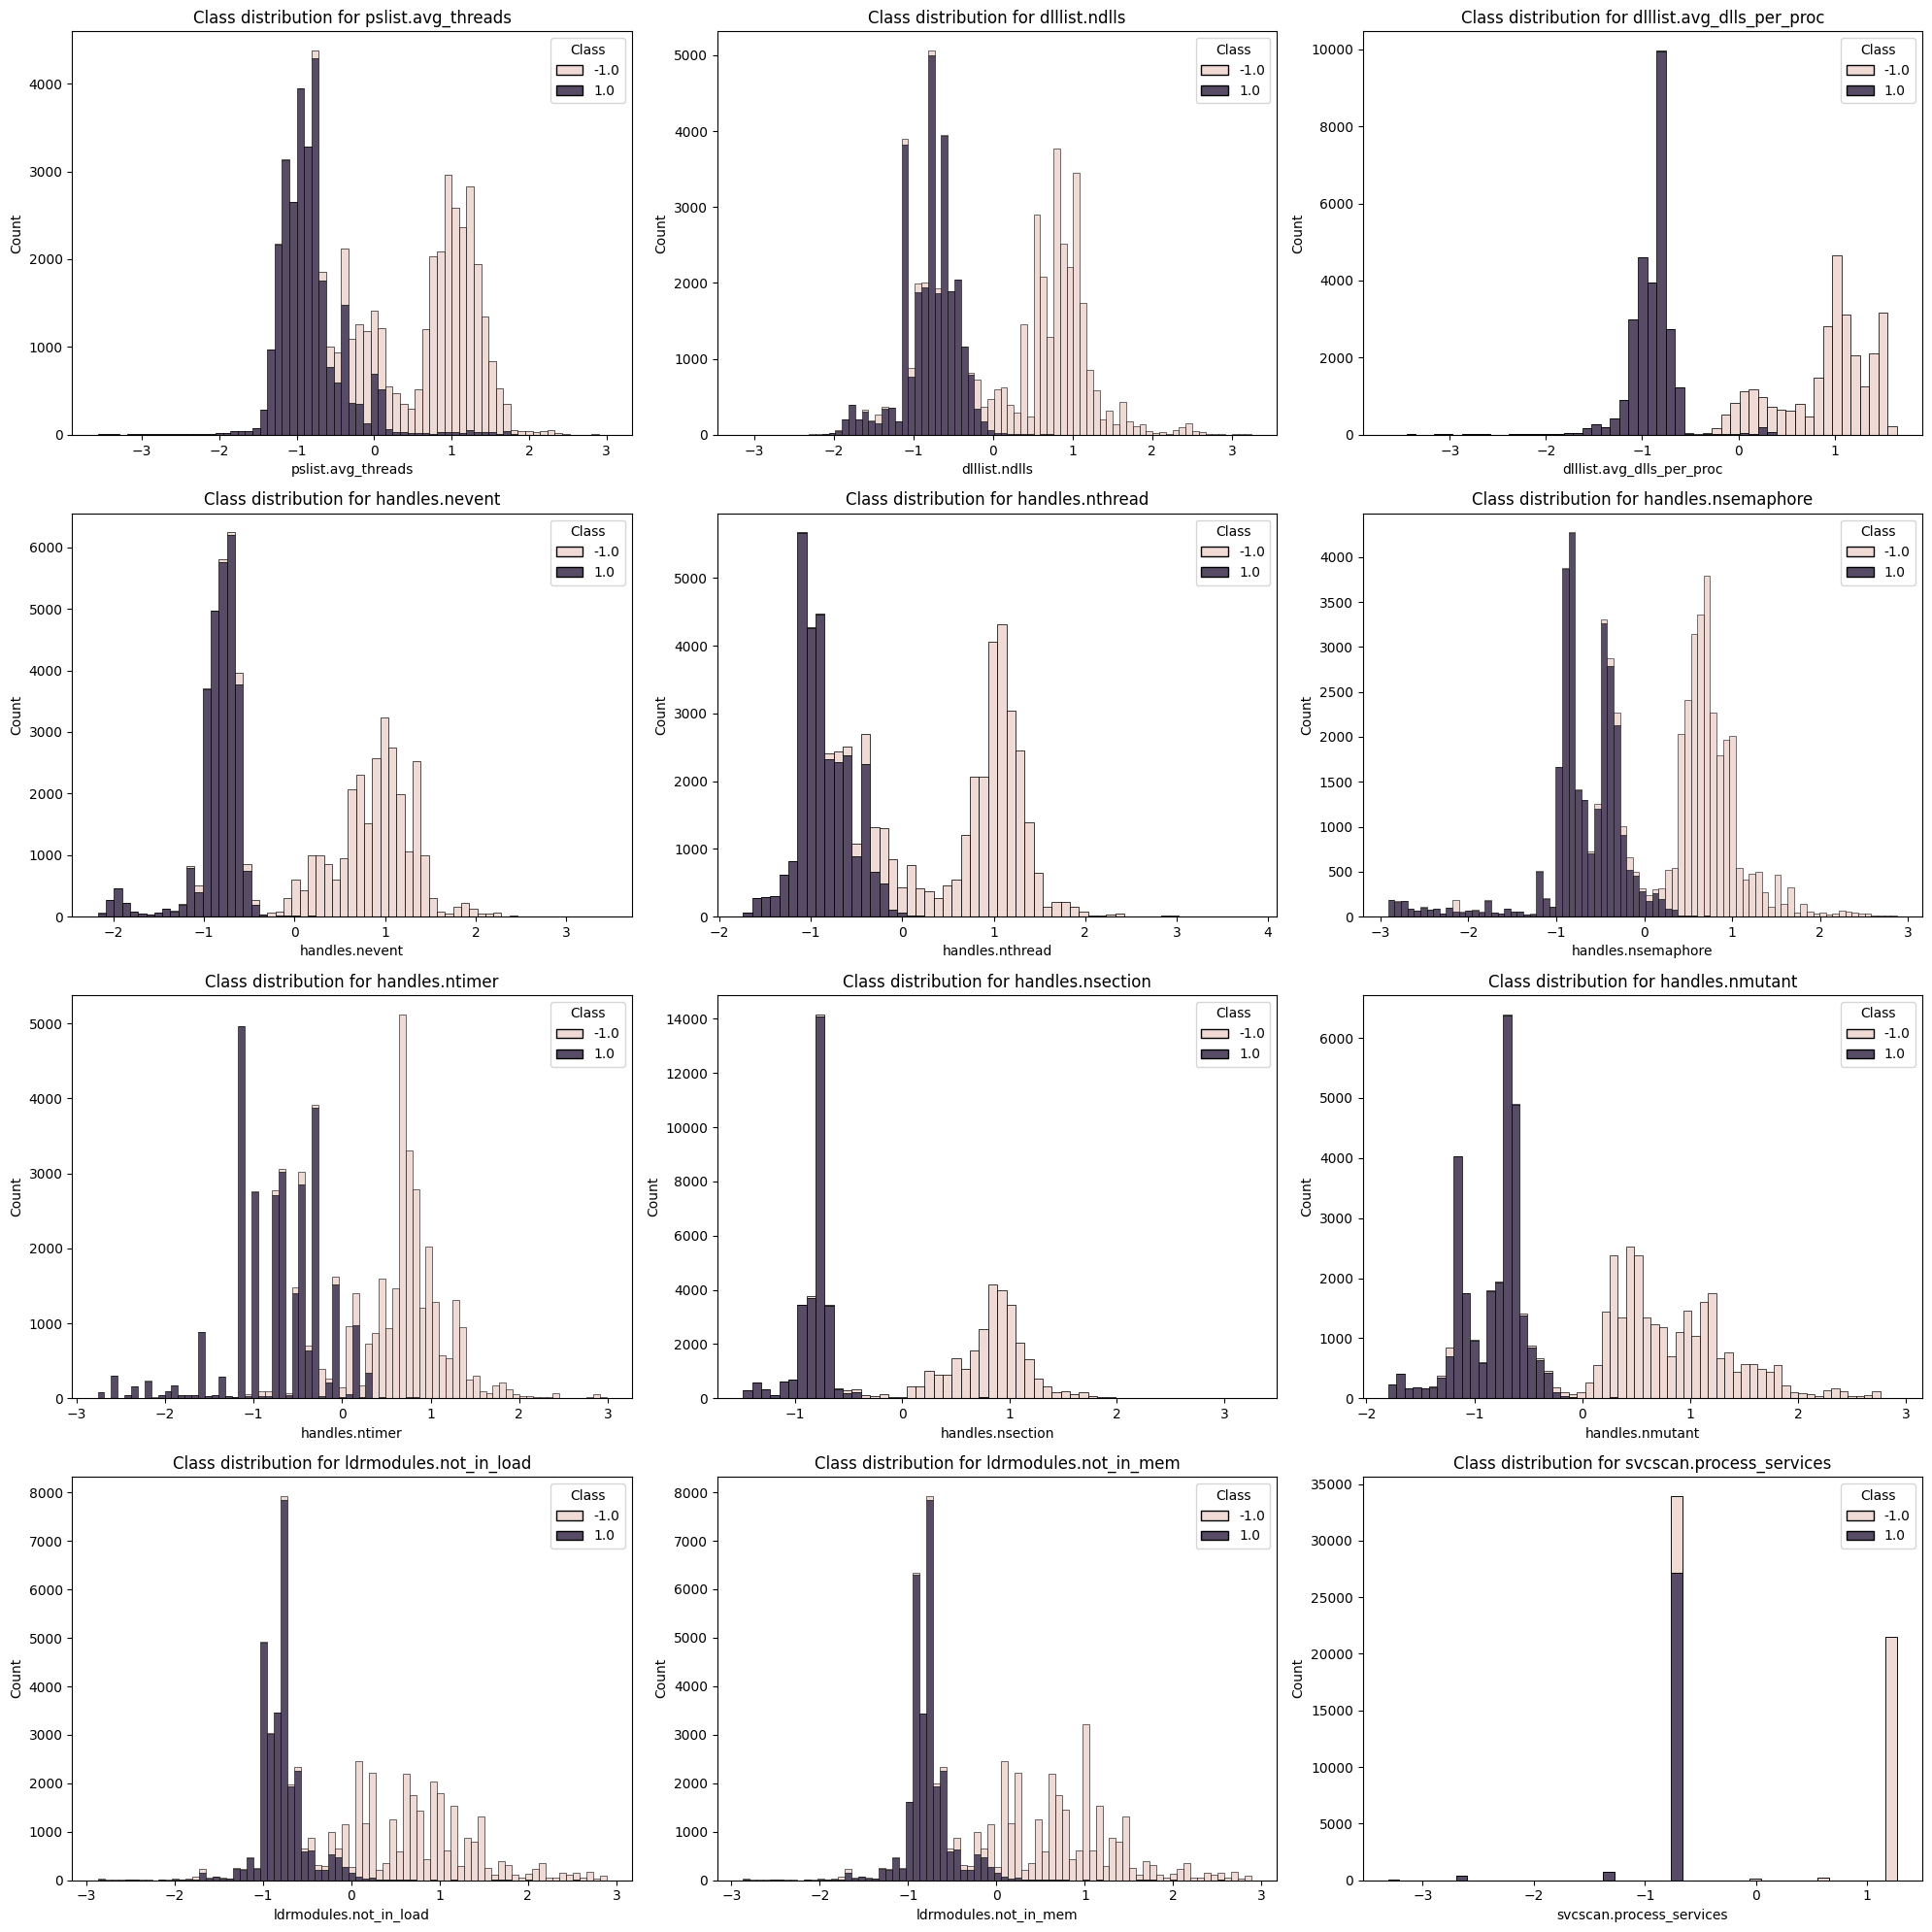

In [37]:
# Set up the subplots using plt.subplots
#fig, axes = plt.subplots(nrows=len(features), ncols=3, figsize=(10, 12))

# Creating individual subplots for each feature
num_features = len(features)
num_rows = 4
num_cols = 3
    
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20,20)) # Adjust the figure size if 
    
# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate through each feature and create a subplot
#features_to_plot =  [col for col in scaled_ds.columns if col != ('Class' or 'Cat1')]

for i, feature in enumerate(features):
    ax = axes[i]
    
    # Use sns.barplot or sns.boxplot depending on the type of visualization you want
    #sns.barplot(x="Class", y=feature, data=scaled_ds, ax=ax, hue = 'Class',alpha=0.8)
    sns.histplot(data=scaled_ds, x=feature, hue='Class', multiple="stack", ax=ax,alpha=0.8)
    
    # Customize subplot (optional)
    ax.set_ylabel("Count")
    ax.set_xlabel(f"{feature}")
    ax.set_title(f"Class distribution for {feature}")

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

Class distrubution tends to follow the negative correlation previously observed. Lower feature value counts are generally indicative of a non-benign classification (represented by `1.0`).

## Model Selection

The primary goal of the model is to make a determination of whether or not a given set of feature values is representative of malicious activity. This can effictively be accomplished with a binary classification with the target label being the Class feature (malcious or benign).
Additional work could be applied to classify the Cat1 (or Cat2) features with a mutli-class classification model to make more granular determinatons based on the specific threat category (if existent). Many models are capable of performing binary classification, so a few will be evalulated for efficacy.

Some examples:
* Naive Bayes
* Logistic Regression
* K-Nearest Neighbours
* Support Vector Machine
* Decision Tree
* Random Forest
* Neural Network


### Testing and Training Data Preparation

The data is split into two portions, the training data for building the model and the test data for evaluating the performance of the model.

In [38]:
# Set X to features to be used for the indepdent variables
X = scaled_ds[features]

# Set y to target label feature
y = scaled_ds['Class']

In [39]:
# Verify X
X.head()

,pslist.avg_threads,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nevent,handles.nthread,handles.nsemaphore,handles.ntimer,handles.nsection,handles.nmutant,ldrmodules.not_in_load,ldrmodules.not_in_mem,svcscan.process_services
0,-0.494957,-0.354192,-0.906971,-0.510780,-0.174547,-0.130533,-0.356018,-0.735578,-0.759695,-0.417368,-0.417521,-0.695219
1,0.119794,0.798092,0.073120,0.234141,0.426759,0.874436,1.180888,0.324877,1.112591,0.861864,0.861812,-0.695219
2,2.130278,0.367501,0.799759,0.525902,1.314001,-0.405577,0.512668,0.546672,0.347277,-0.523970,-0.524132,1.266059
3,1.358973,-1.109241,0.252255,-0.759088,-0.574017,-1.230710,-0.222374,-0.721716,-0.964690,-1.589997,-1.590242,1.266059
4,0.069717,0.776865,0.958987,0.324774,0.056724,1.498575,0.312202,0.588259,1.590913,2.194397,2.194449,-0.695219


In [40]:
# Verify y
y.head()

0   -1.0
1   -1.0
2   -1.0
3   -1.0
4   -1.0
Name: Class, dtype: float64

In [41]:
# Splitting data into traing and testing sets
from sklearn.model_selection import train_test_split

# Set portion of data to be split for test
test_ratio = 0.3

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, random_state=42)

### Min-Max Scaling

Min-Max scaling will set feature values to a range between 0 and 1, while attempting to preserve the distrubtion relations (similar to the StandardScaler used prior). The 0 to 1 range is needed for some model algorithms (e.g., KNN distance skew) that do not handle negative values.

reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

In [42]:
from sklearn.preprocessing import MinMaxScaler

# Instantiate the scaler
scaler = MinMaxScaler()
scaler.fit(X_train)

# T
X_train[X_train.columns] = scaler.transform(X_train[X_train.columns])
X_test[X_test.columns] = scaler.transform(X_test[X_test.columns])

# Impacted accuracy when changed, implies model were sensitive to less distance (-1 to 1 vs. 0 to 1)
# Using manual replacement instead
y_train.replace(-1.0, 0, inplace=True)
y_test.replace(-1.0, 0, inplace=True)

In [43]:
# Verify X_train
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
pslist.avg_threads,39811.0,0.551999,0.149936,0.0,0.417710,0.518030,0.701819,1.0
dlllist.ndlls,39811.0,0.492202,0.141775,0.0,0.371021,0.457007,0.621853,1.0
dlllist.avg_dlls_per_proc,39811.0,0.691687,0.186453,0.0,0.529851,0.667292,0.884127,1.0
handles.nevent,39811.0,0.387799,0.166862,0.0,0.242632,0.296698,0.550853,1.0
handles.nthread,39811.0,0.313587,0.172887,0.0,0.148904,0.255480,0.495087,1.0
handles.nsemaphore,39811.0,0.506198,0.150932,0.0,0.379121,0.514652,0.624542,1.0
handles.ntimer,39811.0,0.489627,0.158735,0.0,0.364706,0.494118,0.623529,1.0
handles.nsection,39811.0,0.321429,0.187513,0.0,0.151652,0.229730,0.509009,1.0
handles.nmutant,39811.0,0.384702,0.202250,0.0,0.227405,0.323615,0.539359,1.0
ldrmodules.not_in_load,39811.0,0.497315,0.161570,0.0,0.361111,0.462963,0.620370,1.0


In [44]:
# Verify X_test
X_test.describe().T

,count,mean,std,min,25%,50%,75%,max
pslist.avg_threads,17063.0,0.553930,0.149298,0.004455,0.420147,0.520849,0.702334,1.018695
dlllist.ndlls,17063.0,0.491791,0.141597,0.069834,0.371021,0.459382,0.621378,1.000475
dlllist.avg_dlls_per_proc,17063.0,0.692880,0.186251,0.004970,0.528900,0.671533,0.884127,1.000980
handles.nevent,17063.0,0.387644,0.166776,-0.001773,0.242854,0.300908,0.549080,0.964325
handles.nthread,17063.0,0.314104,0.172275,0.005291,0.148904,0.256236,0.493575,0.949358
handles.nsemaphore,17063.0,0.505453,0.151797,-0.001832,0.379121,0.516484,0.624542,1.000000
handles.ntimer,17063.0,0.488607,0.159643,0.000000,0.364706,0.494118,0.623529,1.011765
handles.nsection,17063.0,0.321615,0.187692,0.013514,0.151652,0.235736,0.507508,1.027027
handles.nmutant,17063.0,0.384054,0.201838,0.000000,0.227405,0.344023,0.539359,1.005831
ldrmodules.not_in_load,17063.0,0.497387,0.160808,0.000000,0.361111,0.462963,0.620370,1.000000


In [45]:
# Verify y_train
y_train.value_counts()

Class
0.0    20031
1.0    19780
Name: count, dtype: int64

In [46]:
# Verify y_test
y_test.value_counts()

Class
0.0    8612
1.0    8451
Name: count, dtype: int64

### Establish Performance Metrics

The primary native metric assessed is accuracy, defined:
* Accuracy - the ratio of True classifications over all classifications.trix



Sklearn's Classification Report function also includes the following metrics:
* Precision - proportion of positive predictions that are truly positive.
* Recall (Sensitity) - proportion of positive observations that were correctly classified.
* F1-Score -  the harmonic mean of precision and recall.
* Support - the number of the True responses for the class.

reference: http://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html

The Confusion Matrix provides a graph representation of the actual and predicted classes for both the malicous and benign targets. It is read as follows:
* Upper Left: True Negative (TN) - predicted benign, actual is benign (0,0)
* Lower Left: False Negative (FN) - predicted benign, actual is malicious (1,0)
* Upper Right: False Positive (FP) - predicted malicious, actual is benign (0,1)
* Lower Right: True Positive (TP) - predicted malicious, actual is malicous (1,1)

In [57]:
def get_accuracy(model):

    print('-' * 80)
    print(f'\nMODEL: {model}\n')
    
    # Get sklearn accuracy score for given model; e.g., https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB.score
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)  

    print(f'[*] Train Score: {str(train_score)}')
    print(f'[*] Test Score: {str(test_score)}') 

    y_pred = model.predict(X_test)
    print('\n[*] Test Classification Report: \n', metrics.classification_report(y_test, y_pred))

    print('[*] Confusion Matrix on Test data')
    '''
    metrics.ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=list(range(2)), # length of unique values for label
    )
    '''
    cm = metrics.confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.show()
    
    print(f'[*] Test Accuracy: {str(round(test_score, 5) * 100)}%')
    print('-' * 80 + '\n')

In [49]:
def select_optimal_model_parameters(default_model, gridsearch_model):
    """ Calculates accuracy for the default and Gridsearch nominated parameters and appends the model with the highest accuracy to the model evaluation list """
    # save for selection comparison against GridSearch nomination
    y_pred = default_model.predict(X_test)
    default_model_acc = metrics.accuracy_score(y_test, y_pred) *100

    y_pred = gridsearch_model.predict(X_test)
    gridsearch_model_acc = metrics.accuracy_score(y_test, y_pred) *100
    
    # Compare the default and GridSearch paramaters for highest accuracy model to append to evaluation list
    if default_model_acc >= gridsearch_model_acc:
        print('Default parameter model selected')
        models.append(default_model)
    else:
        print('Gridsearch parameter model selected')
        models.append(gridsearch_model)

## Model Building

Building each of the following models in order to evaluate their performance for binary classification (Benign or Malicious):
* K-Nearest Neighbors (KNN)
* Logistic Regression (LR)
* Stochastic Gradient Descent (SGD)
* Multinomial Naive Bayes (MNB)
* Decision Tree (DT)
* Random Forest (RF)
* Support Vector Machine (SVM)

In [50]:
# Instantiate list to store model references are they are created
models = []

### KNN

K-Nearest Neighbors uses a distance function to calculate a given data sample's distance to k (the number of neighbors to consider). The majority classification within the given neighbhors matched (closet distance first) is the predicted classification value assigned to the sample.

For instance: 
* k = 1 (closest neighbor's category is assigned)
* k = 2 (closest neighbor's category is assigned)
* k = 3+ (the category of neighbor majority category is assigned)


As a result, the value of k is an important estimator. One technique to determine a good starting value is to use a Grid Search and Cross Validation to test various values to determine the most accurate model value.

In [51]:
# KNN model
from sklearn.neighbors import KNeighborsClassifier

# Grid Search Cross Validation
from sklearn.model_selection import GridSearchCV

# Instantiate the KNN model with default 
knn = KNeighborsClassifier().fit(X_train, y_train)


In [52]:
# for square root determination
import math 

# A good starting point for a seed value of k is to use the square root of the length of the training data set.
k_seed = int(math.sqrt(X_train.shape[0]))

print(f'Initial k seed (square root of the length of training data): {k_seed}')

# Set list of values to iterate to, up to the seed
k_values = list(range(1,k_seed))

# Set search_space to iterate through all k values (distance metric)
search_space = [{'n_neighbors': k_values}]

Initial k seed (square root of the length of training data): 199


In [53]:
%%time

# Perform grid search cross validation and fit with training data set
grid_search = GridSearchCV(knn, search_space).fit(X_train, y_train)

print(f"GridSearch optimal k estimate: {grid_search.best_estimator_.get_params()['n_neighbors']}")

GridSearch optimal k estimate: 1
CPU times: total: 16min 11s
Wall time: 16min 15s


In [54]:
# set model to gridsearch best estimator value
knn_gs = grid_search.best_estimator_

# set model prediction with X_train data set
y_pred = knn_gs.predict(X_train)

# Check prediction accuracy with training data
accuracy = metrics.accuracy_score(y_train, y_pred) *100

print('Model accuracy with training data: {:.2f}%'.format(accuracy) )

Model accuracy with training data: 100.00%


--------------------------------------------------------------------------------

MODEL: KNeighborsClassifier(n_neighbors=1)

[*] Train Score: 1.0
[*] Test Score: 0.9998241809763816

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


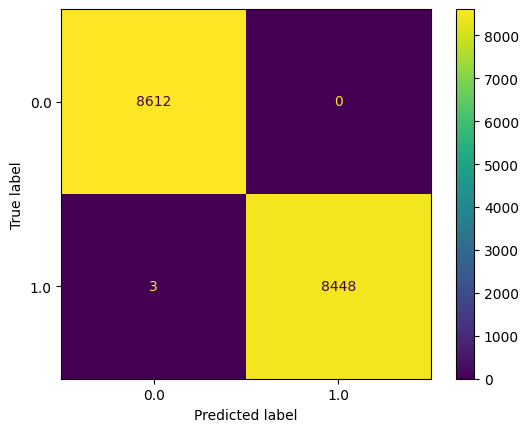

[*] Test Accuracy: 99.982%
--------------------------------------------------------------------------------



In [55]:
# Display performance metrics
get_accuracy(knn_gs)

In [56]:
# Compare the default and GridSearch paramaters for highest accuracy model to append to evaluation list
select_optimal_model_parameters(knn, knn_gs)

Gridsearch parameter model selected


### Logistic Regression

Logistic Regression sets a defined threshold between two possible categorizations and then matches the data sample on the closest probabilty value from a logistic function score.

Variables:
* penalty: the penalty term to use
* C: the inverse of regularization strength 
* max_iter: the maximum number of iterations taken for the solvers to converge.
* solver: the algorithm to use in the optimization problem



Reference: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

--------------------------------------------------------------------------------

MODEL: LogisticRegression()

[*] Train Score: 0.9980156238225616
[*] Test Score: 0.998007384398992

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


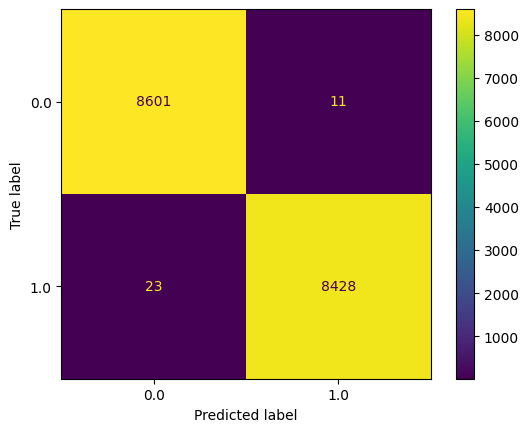

[*] Test Accuracy: 99.801%
--------------------------------------------------------------------------------



In [58]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
lr=LogisticRegression()
lr.fit(X_train, y_train)

# Check to base model's performance with default parameters
get_accuracy(lr)

In [59]:
%%time

# Set the parameter options for the GridSearch evalation
grid_values = {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000], 'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'], 'max_iter': [10, 100, 1000]}

# Instantiate and fit the GridSearch run
grid_search = GridSearchCV(lr, param_grid=grid_values).fit(X_train, y_train)

CPU times: total: 6min 16s
Wall time: 6min 13s


In [60]:
# set model to GridsSearch best estimator value
lr_gs = grid_search.best_estimator_

# Review the GridSearch nominated optimal model parameters
grid_search.best_estimator_.get_params()

{'C': 1000,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l1',
 'random_state': None,
 'solver': 'liblinear',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

--------------------------------------------------------------------------------

MODEL: LogisticRegression(C=1000, penalty='l1', solver='liblinear')

[*] Train Score: 0.9988696591394338
[*] Test Score: 0.999003692199496

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


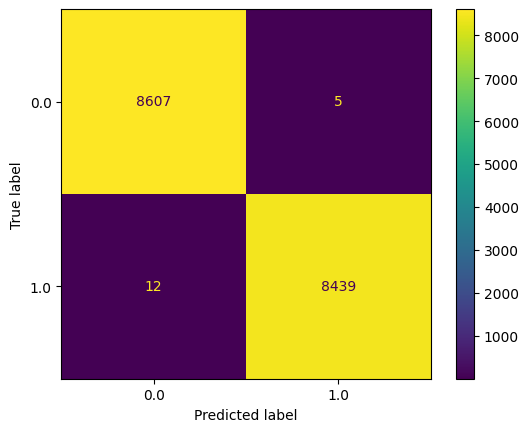

[*] Test Accuracy: 99.9%
--------------------------------------------------------------------------------



In [61]:
# Display performance metrics
get_accuracy(lr_gs)

In [62]:
# Compare the default and GridSearch paramaters for highest accuracy model to append to evaluation list
select_optimal_model_parameters(lr, lr_gs)

Gridsearch parameter model selected


### Stochastic Gradient Descent

Implemented in SKLearn as another solver model for performing Logistic Regression, Stochastic Gradient Descent is another binary classifier which attempts to optimize based on measures loss. 

The name is derived from:
* Stochastic = meaning random
* Gradient = a multi-dimensional analog for slope
* Descent = in relation to loss


Reference: https://scikit-learn.org/stable/modules/sgd.html

--------------------------------------------------------------------------------

MODEL: SGDClassifier()

[*] Train Score: 0.9978900303936098
[*] Test Score: 0.9980659907401981

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


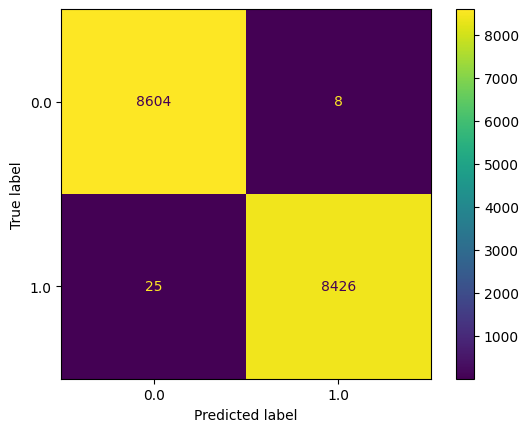

[*] Test Accuracy: 99.807%
--------------------------------------------------------------------------------

CPU times: total: 219 ms
Wall time: 211 ms


In [63]:
%%time
#logistic regression with stochastic gradient decent
from sklearn.linear_model import SGDClassifier

sgd=SGDClassifier()
sgd.fit(X_train, y_train)

#models.append(sgd)

# Check to base model's performance with default parameters
get_accuracy(sgd)

In [64]:
%%time

# Set the parameter options for the GridSearch evalation; re
# ref: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html
grid_values = {
    'penalty': ['l1','l2'], 
    'loss': ['hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'],
    'max_iter': [10, 100, 1000]
}

# Instantiate and fit the GridSearch run
grid_search = GridSearchCV(sgd, param_grid=grid_values).fit(X_train, y_train)

CPU times: total: 1min 4s
Wall time: 1min 4s


In [65]:
# set model to GridsSearch best estimator value
sgd_gs = grid_search.best_estimator_

# Review the GridSearch nominated optimal model parameters
grid_search.best_estimator_.get_params()

{'alpha': 0.0001,
 'average': False,
 'class_weight': None,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.0,
 'fit_intercept': True,
 'l1_ratio': 0.15,
 'learning_rate': 'optimal',
 'loss': 'modified_huber',
 'max_iter': 10,
 'n_iter_no_change': 5,
 'n_jobs': None,
 'penalty': 'l1',
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

--------------------------------------------------------------------------------

MODEL: SGDClassifier(loss='modified_huber', max_iter=10, penalty='l1')

[*] Train Score: 0.9984426414809977
[*] Test Score: 0.9982418097638165

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


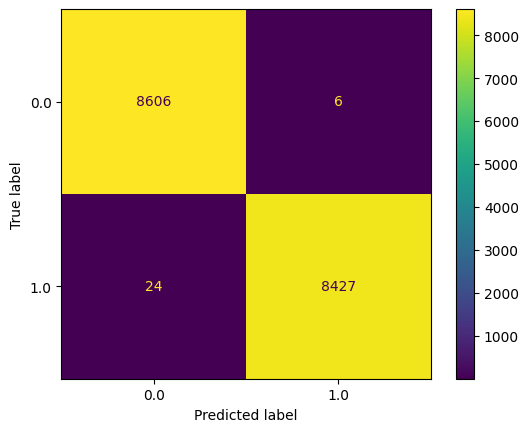

[*] Test Accuracy: 99.824%
--------------------------------------------------------------------------------



In [66]:
# Display performance metrics
get_accuracy(sgd_gs)

In [67]:
# Compare the default and GridSearch paramaters for highest accuracy model to append to evaluation list
select_optimal_model_parameters(sgd, sgd_gs)

Gridsearch parameter model selected


### Naive Bayes

Originating from Bayes' theorem, Mutlinomial Naïve Bayes (MNB) is a probabilitic learning model that determines classification based on likelihood determination. It is considered naïve due to the assumption that all features (independent variables) are independent of each other outside of the target label.

https://www.springboard.com/blog/data-analytics/naive-bayes-classification/

--------------------------------------------------------------------------------

MODEL: SGDClassifier()

[*] Train Score: 0.9978900303936098
[*] Test Score: 0.9980659907401981

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


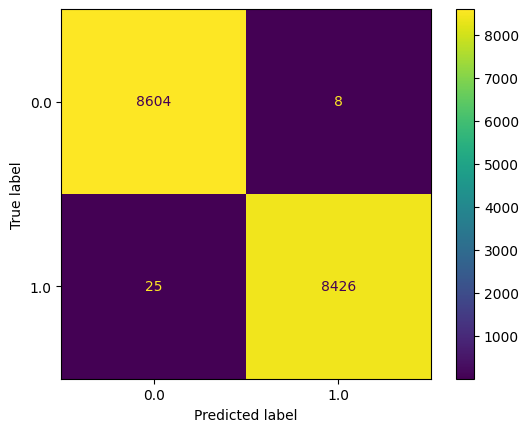

[*] Test Accuracy: 99.807%
--------------------------------------------------------------------------------

CPU times: total: 188 ms
Wall time: 175 ms


In [68]:
%%time

from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB().fit(X_train, y_train)

# Check to base model's performance with default parameters
get_accuracy(sgd)

In [69]:
%%time

# Set the parameter options for the GridSearch evalation
grid_values = {
    'alpha': [50, 15, 10, 5, 1, 0.5, 0.3, 0.1, 0.05, 0.03, 0.02, 0.01,  0.001],
    'fit_prior': [True, False],
}

# Instantiate and fit the GridSearch run
grid_search = GridSearchCV(mnb, param_grid=grid_values).fit(X_train, y_train)

CPU times: total: 2 s
Wall time: 1.94 s


In [71]:
# set model to GridsSearch best estimator value
mnb_gs = grid_search.best_estimator_

# Review the GridSearch nominated optimal model parameters
grid_search.best_estimator_.get_params()

{'alpha': 50, 'class_prior': None, 'fit_prior': False, 'force_alpha': True}

--------------------------------------------------------------------------------

MODEL: MultinomialNB(alpha=50, fit_prior=False)

[*] Train Score: 0.9804576624551004
[*] Test Score: 0.9819492469085155

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      8612
         1.0       0.98      0.99      0.98      8451

    accuracy                           0.98     17063
   macro avg       0.98      0.98      0.98     17063
weighted avg       0.98      0.98      0.98     17063

[*] Confusion Matrix on Test data


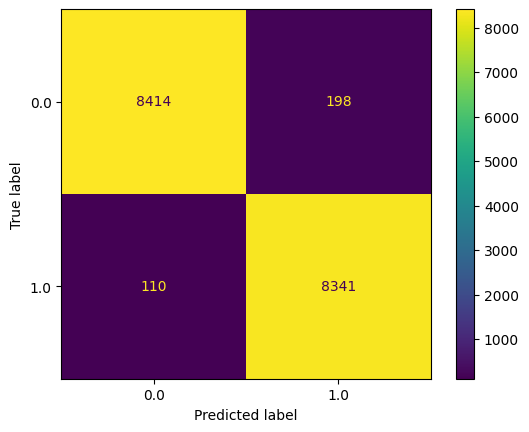

[*] Test Accuracy: 98.195%
--------------------------------------------------------------------------------



In [68]:
# Display performance metrics
get_accuracy(mnb_gs)

In [72]:
# Compare the default and GridSearch paramaters for highest accuracy model to append to evaluation list
select_optimal_model_parameters(mnb, mnb_gs)

Gridsearch parameter model selected


### Decision Tree

Decision Tree based their classificaton on a divide and conquer technique that recursively splits data into branches based on the most signficant attribute at each node. Features with higher relative importance occur higher (or earlier) in the decisioning nodes. The branches terminate in leaf nodes, which represent a final prediction classification.

Reference: https://scikit-learn.org/stable/modules/tree.html#decision-trees

--------------------------------------------------------------------------------

MODEL: DecisionTreeClassifier()

[*] Train Score: 1.0
[*] Test Score: 0.9991209048819082

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


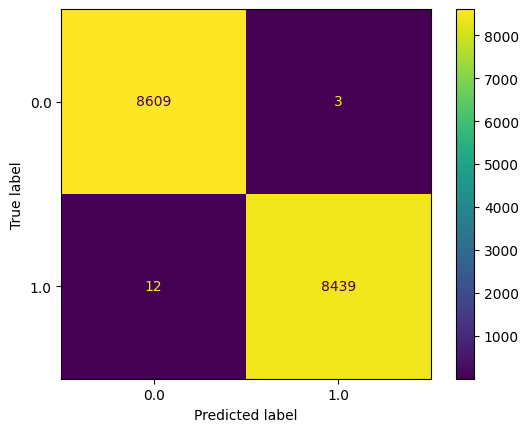

[*] Test Accuracy: 99.912%
--------------------------------------------------------------------------------

CPU times: total: 344 ms
Wall time: 345 ms


In [73]:
%%time

from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

#models.append(dtc)

# Display performance metrics
get_accuracy(dtc)

In [74]:
%%time

# Set the parameter options for the GridSearch evalation
# parameter reference: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
grid_values = {
    'criterion':['gini','entropy'],
    'max_depth':[4,5,6,7,8,9,10,11,12,15,20,30,40,50,70,90,120,150]
}

# Instantiate and fit the GridSearch run
grid_search = GridSearchCV(dtc, param_grid=grid_values).fit(X_train, y_train)

CPU times: total: 16.5 s
Wall time: 16.8 s


In [75]:
# set model to GridsSearch best estimator value
dtc_gs = grid_search.best_estimator_

# Review the GridSearch nominated optimal model parameters
grid_search.best_estimator_.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 10,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

--------------------------------------------------------------------------------

MODEL: DecisionTreeClassifier(criterion='entropy', max_depth=10)

[*] Train Score: 0.9999748813142096
[*] Test Score: 0.9994139365879389

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


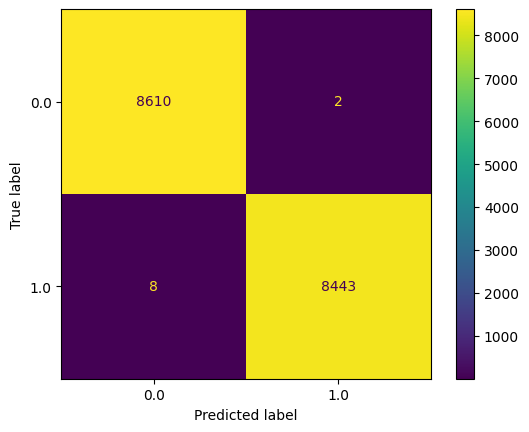

[*] Test Accuracy: 99.941%
--------------------------------------------------------------------------------



In [76]:
# Display performance metrics
get_accuracy(dtc_gs)

In [77]:
# Compare the default and GridSearch paramaters for highest accuracy model to append to evaluation list
select_optimal_model_parameters(dtc, dtc_gs)

Gridsearch parameter model selected


### Random Forest

The Random Forest model is an ensemble of Decision Trees from the prior evaluation. The model builds multiple trees,  which are trained on subsets of the training data, and combines their predictions to optimize overall performance. Random Forests can work well on larger datasets due to their bootstrap samples (subset selection), which can help avoid the curse of dimensionality resultant from too many feature variable.

Reference: https://scikit-learn.org/stable/modules/ensemble.html

--------------------------------------------------------------------------------

MODEL: RandomForestClassifier(max_depth=9, n_estimators=30)

[*] Train Score: 0.9999246439426289
[*] Test Score: 0.9997655746351756

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


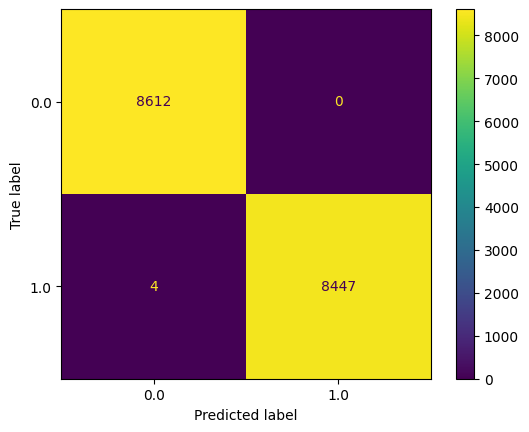

[*] Test Accuracy: 99.977%
--------------------------------------------------------------------------------

CPU times: total: 1.03 s
Wall time: 1.03 s


In [78]:
%%time

from sklearn.ensemble import RandomForestClassifier

# n_estimators = number of desission trees
rf = RandomForestClassifier(n_estimators=30,max_depth=9)
rf.fit(X_train, y_train)

# models.append(rf)

# Display performance metrics
get_accuracy(rf)

In [79]:
%%time

# Set the parameter options for the GridSearch evalation
# parameter reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
grid_values = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features': ['sqrt', 'log2', None]
}

# Instantiate and fit the GridSearch run
grid_search = GridSearchCV(rf, param_grid=grid_values).fit(X_train, y_train)

CPU times: total: 39.2 s
Wall time: 39.3 s


In [80]:
# set model to GridSearch best estimator value
rf_gs = grid_search.best_estimator_

# Review the GridSearch nominated optimal model parameters
grid_search.best_estimator_.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'log_loss',
 'max_depth': 9,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 30,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [81]:
# Compare the default and GridSearch paramaters for highest accuracy model to append to evaluation list
select_optimal_model_parameters(rf, rf_gs)

Default parameter model selected


### SVM

A Support Vector Machine (SVM) is a supervised learning model primarily used for classification and regression. The model attempts to find the optimal hyperplane in Nth dimensional space (associated to feature length) that can most effectively separate different feature values into distinct classes.

Reference: https://scikit-learn.org/stable/modules/svm.html#support-vector-machines:

--------------------------------------------------------------------------------

MODEL: LinearSVC(C=0.0001)

[*] Train Score: 0.9898269322549044
[*] Test Score: 0.990564379065815

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      8612
         1.0       0.99      1.00      0.99      8451

    accuracy                           0.99     17063
   macro avg       0.99      0.99      0.99     17063
weighted avg       0.99      0.99      0.99     17063

[*] Confusion Matrix on Test data


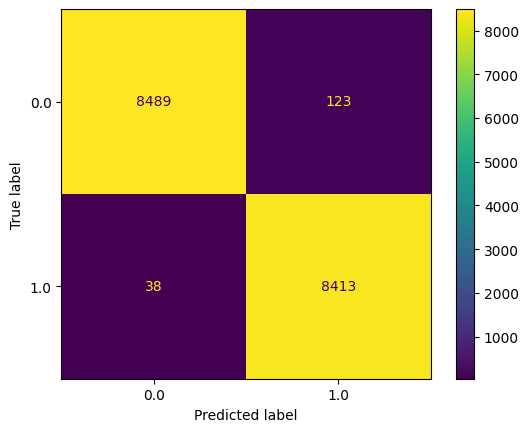

[*] Test Accuracy: 99.056%
--------------------------------------------------------------------------------

CPU times: total: 250 ms
Wall time: 239 ms


In [82]:
%%time

# Linear Support Vector Classification, ref: https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
from sklearn.svm import LinearSVC

svm=LinearSVC(C=0.0001)
svm.fit(X_train, y_train)

#models.append(svm)

# Display performance metrics
get_accuracy(svm)

In [83]:
%%time

# Set the parameter options for the GridSearch evalation
# parameter reference: https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
grid_values = {
    'penalty': ['l1','l2'], 
    'loss': ['hinge', 'squared_hinge'],
    'max_iter': [10, 100, 1000]
}

# Instantiate and fit the GridSearch run
grid_search = GridSearchCV(svm, param_grid=grid_values).fit(X_train, y_train)

CPU times: total: 1.8 s
Wall time: 1.81 s


In [84]:
# set model to GridsSearch best estimator value
svm_gs = grid_search.best_estimator_

# Review the GridSearch nominated optimal model parameters
grid_search.best_estimator_.get_params()

{'C': 0.0001,
 'class_weight': None,
 'dual': 'auto',
 'fit_intercept': True,
 'intercept_scaling': 1,
 'loss': 'squared_hinge',
 'max_iter': 10,
 'multi_class': 'ovr',
 'penalty': 'l2',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

--------------------------------------------------------------------------------

MODEL: LinearSVC(C=0.0001, max_iter=10)

[*] Train Score: 0.9898269322549044
[*] Test Score: 0.990564379065815

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      8612
         1.0       0.99      1.00      0.99      8451

    accuracy                           0.99     17063
   macro avg       0.99      0.99      0.99     17063
weighted avg       0.99      0.99      0.99     17063

[*] Confusion Matrix on Test data


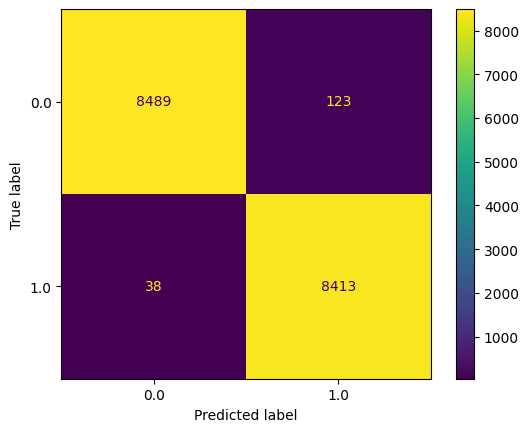

[*] Test Accuracy: 99.056%
--------------------------------------------------------------------------------



In [85]:
# Display performance metrics
get_accuracy(svm_gs)

In [86]:
# Compare the default and GridSearch paramaters for highest accuracy model to append to evaluation list
select_optimal_model_parameters(svm, svm_gs)

Default parameter model selected


## Model Evaluation

Running performance tests against each of the established models.

--------------------------------------------------------------------------------

MODEL: KNeighborsClassifier(n_neighbors=1)

[*] Train Score: 1.0
[*] Test Score: 0.9998241809763816

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


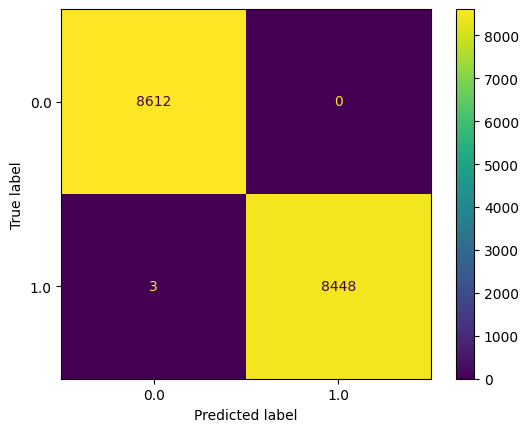

[*] Test Accuracy: 99.982%
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------

MODEL: LogisticRegression(C=1000, penalty='l1', solver='liblinear')

[*] Train Score: 0.9988696591394338
[*] Test Score: 0.999003692199496

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


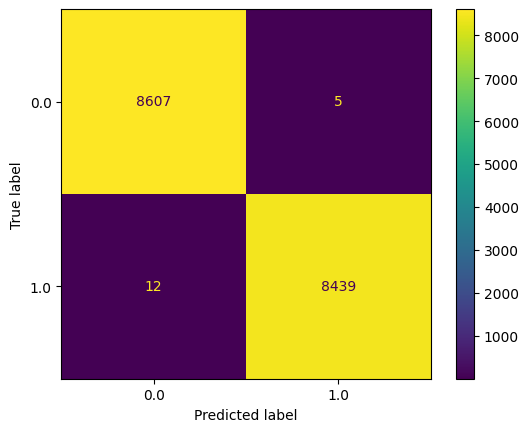

[*] Test Accuracy: 99.9%
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------

MODEL: SGDClassifier(loss='modified_huber', max_iter=10, penalty='l1')

[*] Train Score: 0.9984426414809977
[*] Test Score: 0.9982418097638165

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


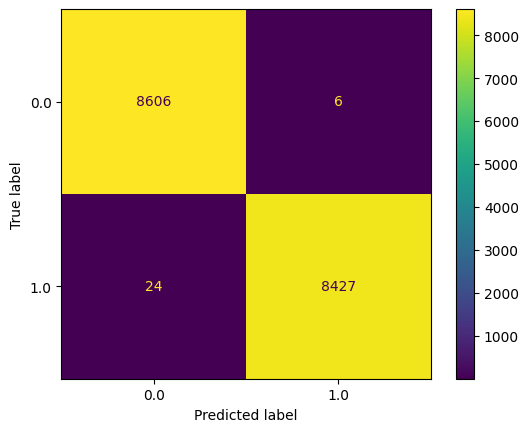

[*] Test Accuracy: 99.824%
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------

MODEL: MultinomialNB(alpha=50, fit_prior=False)

[*] Train Score: 0.9804576624551004
[*] Test Score: 0.9819492469085155

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      8612
         1.0       0.98      0.99      0.98      8451

    accuracy                           0.98     17063
   macro avg       0.98      0.98      0.98     17063
weighted avg       0.98      0.98      0.98     17063

[*] Confusion Matrix on Test data


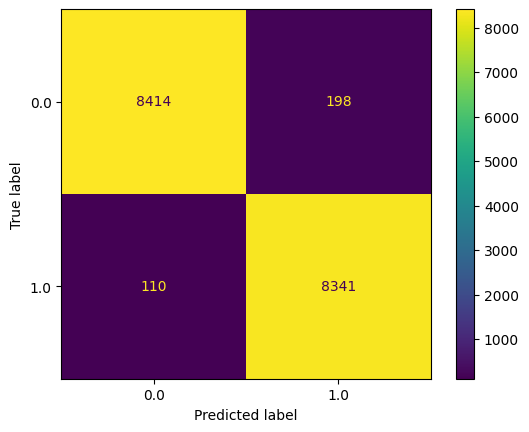

[*] Test Accuracy: 98.195%
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------

MODEL: DecisionTreeClassifier(criterion='entropy', max_depth=10)

[*] Train Score: 0.9999748813142096
[*] Test Score: 0.9994139365879389

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


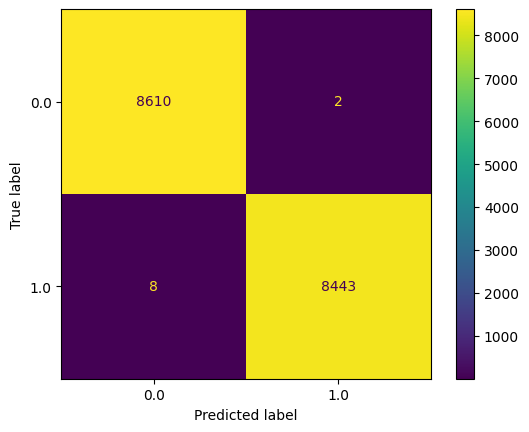

[*] Test Accuracy: 99.941%
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------

MODEL: RandomForestClassifier(max_depth=9, n_estimators=30)

[*] Train Score: 0.9999246439426289
[*] Test Score: 0.9997655746351756

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8612
         1.0       1.00      1.00      1.00      8451

    accuracy                           1.00     17063
   macro avg       1.00      1.00      1.00     17063
weighted avg       1.00      1.00      1.00     17063

[*] Confusion Matrix on Test data


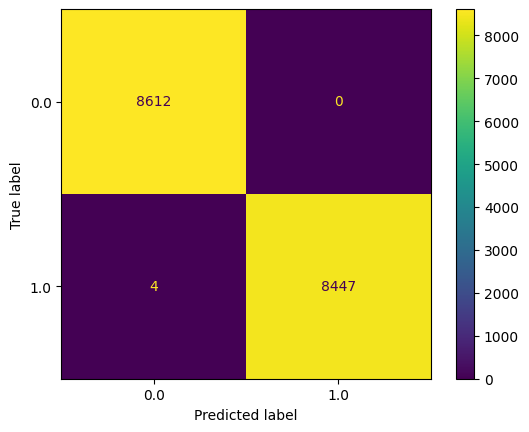

[*] Test Accuracy: 99.977%
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------

MODEL: LinearSVC(C=0.0001)

[*] Train Score: 0.9898269322549044
[*] Test Score: 0.990564379065815

[*] Test Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      8612
         1.0       0.99      1.00      0.99      8451

    accuracy                           0.99     17063
   macro avg       0.99      0.99      0.99     17063
weighted avg       0.99      0.99      0.99     17063

[*] Confusion Matrix on Test data


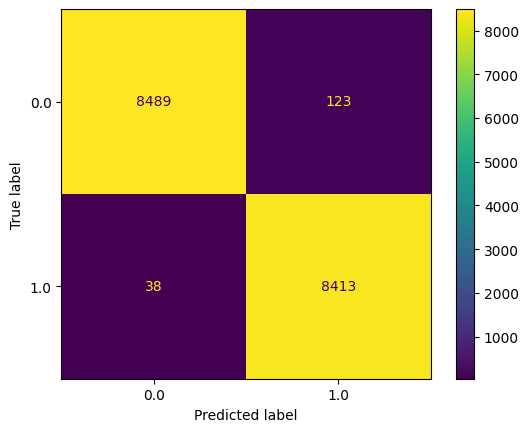

[*] Test Accuracy: 99.056%
--------------------------------------------------------------------------------



In [87]:
for model in models:
    get_accuracy(model)

In [88]:
def get_metrics(model_list):
    
    """ Derives performance metrics from a model list and returns results in a dataframe """
    
    report = {}
    row_iter = 0
    # iterate through models
    for model in model_list:
        
        
        if str(model).startswith('KNeighborsClassifier'):
            model_name = 'K-Nearest Neighbors (knn)'
        elif str(model).startswith('LogisticRegression'):
            model_name = 'Logistic Regression (lr)'
        elif str(model).startswith('SGDClassifier'):
            model_name = 'Stochastic Gradient Descent (sgd)'
        elif str(model).startswith('MultinomialNB'):
            model_name = 'Naive Bayes (mnb)'
        elif str(model).startswith('DecisionTreeClassifier'):
            model_name = 'Decision Tree (dt)'
        elif str(model).startswith('RandomForestClassifier'):
            model_name = 'Random Forest (rf)'
        elif str(model).startswith('LinearSVC'):
            model_name = 'Support Vector Machine (svm)'
        
        report[row_iter] = {}
        report[row_iter]['Model'] = model_name
        report[row_iter]['Test Ratio'] = test_ratio

        y_pred = model.predict(X_test)

        # Classification report data        
        
        report[row_iter]['Accuracy'] = metrics.accuracy_score(y_test, y_pred) * 100
        # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
        
        report[row_iter]['Precision'] = metrics.precision_score(y_test, y_pred) * 100
        # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html
        
        report[row_iter]['Recall'] = metrics.recall_score(y_test, y_pred) * 100
        # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html
        
        report[row_iter]['F1-Score'] = metrics.f1_score(y_test, y_pred) * 100
        # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
    
        # Confusion Matrix
        cm = metrics.confusion_matrix(y_test, y_pred)
        report[row_iter]['TN'] = cm[0,0]
        report[row_iter]['FN'] = cm[1,0]
        report[row_iter]['FP'] = cm[0,1]
        report[row_iter]['TP'] = cm[1,1]

        row_iter += 1

    # Convert nest dictionary to Pandas dataframe
    report_df = pd.DataFrame(report).transpose()
    return report_df

In [89]:
report = get_metrics(models)

In [90]:
report = report.astype({'Accuracy':'float', 'Precision': 'float', 'Recall': 'float', 'F1-Score': 'float'})
report.nlargest(7, 'Accuracy')

,Model,Test Ratio,Accuracy,Precision,Recall,F1-Score,TN,FN,FP,TP
0,K-Nearest Neighbors (knn),0.3,99.982418,100.000000,99.964501,99.982247,8612,3,0,8448
5,Random Forest (rf),0.3,99.976557,100.000000,99.952668,99.976329,8612,4,0,8447
4,Decision Tree (dt),0.3,99.941394,99.976317,99.905337,99.940814,8610,8,2,8443
1,Logistic Regression (lr),0.3,99.900369,99.940786,99.858005,99.899379,8607,12,5,8439
2,Stochastic Gradient Descent (sgd),0.3,99.824181,99.928851,99.716010,99.822317,8606,24,6,8427
6,Support Vector Machine (svm),0.3,99.056438,98.559044,99.550349,99.052216,8489,38,123,8413
3,Naive Bayes (mnb),0.3,98.194925,97.681227,98.698379,98.187169,8414,110,198,8341


In [91]:
def plot_model_feature(feature):
    
    # Basic barplot with coloration for the model (x)
    ax = sns.barplot(
        data=report,
        x='Model',
        y=feature,
        hue = 'Model',
    )

    # Set figure size
    sns.set(rc={'figure.figsize':(6,6)})

    # Add legend for models
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

    # Add bar values
    for i in ax.containers:
        ax.bar_label(i,)

    # Hide bottom xticks
    plt.tick_params(
        axis='x',          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        labelbottom=False
    ) # labels along the bottom edge are off

    # Set minimum scale to lowest feature value
    low = report[feature].min() - 0.2
    plt.ylim(low, 100)
    
    # Add buffer space to side x margin to read labels easier
    ax.margins(x=0.10) 

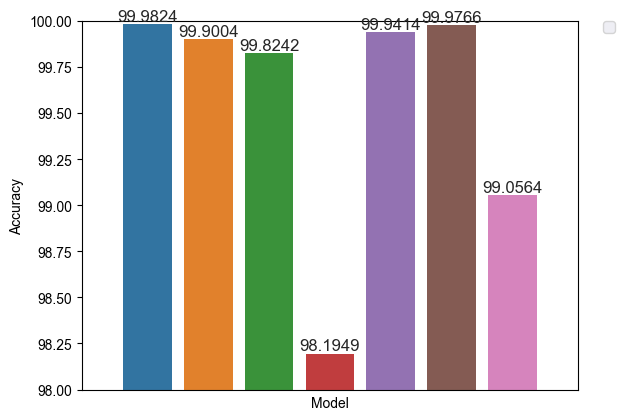

In [92]:
plot_model_feature('Accuracy')

### Most Accurate Model
Tie - 99.982%
* K-Nearest Nieghbors
* Random Forest

## Final Analysis

The accuracy metrics indicated a tie between two model builds, those with the K-Nearest Neighbors and Random Forest algorithms. The least accurate model algorithm in this use case was Naive Bayes.

Accuracy is measured as rate of the true classifications over the rate of total classifications as follows: 
$$ Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

While accuracy is a strong indicator of the effectiveness of the model, it is not always the best metric. Depending on the use case of the malware detection, there may be different optimizations.

An example may be for a security operations center where analysts frequently review large volumes of telemetry for detection. In this case, minimization of false positive errors may be most beneficial.
A better metric would be precision, calculated as follows:

$$ Precision = \frac{TP}{TP + FP} $$

In [93]:
report[['Model', 'Precision']].nlargest(7, 'Precision')

,Model,Precision
0,K-Nearest Neighbors (knn),100.000000
5,Random Forest (rf),100.000000
4,Decision Tree (dt),99.976317
1,Logistic Regression (lr),99.940786
2,Stochastic Gradient Descent (sgd),99.928851
6,Support Vector Machine (svm),98.559044
3,Naive Bayes (mnb),97.681227


Another scenario might be a highly secure environment where the desire is ensure that there is the highest probability for detection. In this case, minimization of false negatives would be ideal. 

This can be accomplished by prioritizing recall, calculated as follows:

$$ Recall  = \frac{TP}{TP + FN}$$

The F1-Score is a method to find a balance between these two and is calculated as:

$$ F_{1} = \frac{2 \cdot precision \cdot recall}{precision + recall} = \frac{TP}{TP + \frac{1}{2}(FP + FN)} $$

In [94]:
report[['Model', 'Recall']].nlargest(7, 'Recall')

,Model,Recall
0,K-Nearest Neighbors (knn),99.964501
5,Random Forest (rf),99.952668
4,Decision Tree (dt),99.905337
1,Logistic Regression (lr),99.858005
2,Stochastic Gradient Descent (sgd),99.716010
6,Support Vector Machine (svm),99.550349
3,Naive Bayes (mnb),98.698379


In [92]:
report[['Model', 'F1-Score']].nlargest(7, 'F1-Score')

,Model,F1-Score
0,K-Nearest Neighbors (knn),99.982247
5,Random Forest (rf),99.982247
4,Decision Tree (dt),99.946723
1,Logistic Regression (lr),99.875673
2,Stochastic Gradient Descent (sgd),99.822506
6,Support Vector Machine (svm),99.046386
3,Naive Bayes (mnb),98.187169


In this testing, the model efficacy order remained constant regardless of the metric used.

## Future Work

Some suggested follow on actions would be to:
* Expand the parameters within the GridSearch functions to further identify more performant configurations.
* Attempt with additional test ratio splits of the data, both higher and lower, to identify an optimal over/under fitting balance.
* Include additional models, such as neural networks, for evaluation.

## Appendix: Model Save/Load

In [96]:
def export_model(source_model, destination_file):
    model_file = open(destination_file, 'wb') 
    pickle.dump(source_model, model_file)  
    model_file.close()
                
def import_model(destination_file):
    return pickle.load(open(destination_file, 'rb'))

export_model(knn_gs, 'knn_gs.pickle')